# 🎯 Entrenamiento YOLOv8 - Detección de Mobs de Minecraft

Este notebook entrena un modelo YOLOv8 para detectar mobs de Minecraft usando bounding boxes exportados desde CVAT.

## 📦 Requisitos
- ✅ Python 3.10.11 (entorno virtual `.venv`)
- ✅ Revisar librerias en requirements
- ✅ Anotaciones en formato YOLO 1.1 desde CVAT
- ✅ GPU opcional, podria funcionar con CPU también

## 🚀 Instrucciones
1. Asegúrate que el kernel seleccionado sea: **Python 3.10.11 (.venv)**
2. Ejecuta las celdas en orden

## ===== Configuracion de dataset, limpieza y configuración de modo de entrenamiento ===== 

In [11]:
# ========================
# 📦 IMPORTAR LIBRERÍAS Y CONFIGURACIÓN
# ========================
import os
import sys
import shutil
import random
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
import torch
from ultralytics import YOLO

# Verificar instalación
print(f"🐍 Python: {sys.version}")
print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ OpenCV: {cv2.__version__}")
print(f"   GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print(f"   Device: CPU")

# ========================
# 1️⃣ CONFIGURACIÓN
# ========================
CVAT_FOLDERS = {
    "aldeanos": r"C:\Users\Usuario\Desktop\Dataset\Imagenes_etiquetadas_bbox\imagenes_aldeano_etiquetados",
    "creepers": r"C:\Users\Usuario\Desktop\Dataset\Imagenes_etiquetadas_bbox\Imagenes_creeper_etiquetados",
    "vacas": r"C:\Users\Usuario\Desktop\Dataset\Imagenes_etiquetadas_bbox\Imagenes_vacas_etiquetados",
}

OUTPUT_DIR = Path(r"C:\Users\Usuario\Desktop\Dataset\mobs-yolo")

# Crear estructura YOLOv8
for split in ['train', 'val']:
    (OUTPUT_DIR / f"images/{split}").mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / f"labels/{split}").mkdir(parents=True, exist_ok=True)

print(f"\n✅ Estructura creada en: {OUTPUT_DIR}")

# ========================
# 2️⃣ REORGANIZAR DATASET
# ========================
def reorganize_cvat_to_yolo(cvat_folders, output_dir, val_split=0.2, seed=42):
    """Reorganiza imágenes y anotaciones de CVAT a formato YOLOv8"""
    random.seed(seed)
    all_files = []
    
    for class_name, cvat_path in cvat_folders.items():
        cvat_path = Path(cvat_path)
        obj_train_data = cvat_path / "obj_train_data"
        
        if not obj_train_data.exists():
            print(f"⚠️ No se encuentra obj_train_data en {cvat_path}")
            continue
        
        txt_files = list(obj_train_data.glob("*.txt"))
        for txt_file in txt_files:
            img_name = txt_file.stem
            img_file = None
            for ext in ['.jpg', '.png', '.jpeg']:
                potential_img = obj_train_data / f"{img_name}{ext}"
                if potential_img.exists():
                    img_file = potential_img
                    break
            
            if img_file:
                all_files.append((img_file, txt_file, class_name))
    
    random.shuffle(all_files)
    split_idx = int(len(all_files) * (1 - val_split))
    train_files = all_files[:split_idx]
    val_files = all_files[split_idx:]
    
    splits = {'train': train_files, 'val': val_files}
    
    for split_name, file_list in splits.items():
        for img_file, txt_file, class_name in file_list:
            dst_img = output_dir / f"images/{split_name}/{img_file.name}"
            shutil.copy2(img_file, dst_img)
            
            dst_txt = output_dir / f"labels/{split_name}/{txt_file.name}"
            shutil.copy2(txt_file, dst_txt)
    
    print(f"\n📊 Dataset reorganizado:")
    print(f"   Train: {len(train_files)} imágenes")
    print(f"   Val: {len(val_files)} imágenes")
    print(f"   Total: {len(all_files)} imágenes")
    
    return len(train_files), len(val_files)

train_count, val_count = reorganize_cvat_to_yolo(CVAT_FOLDERS, OUTPUT_DIR, val_split=0.2)

# ========================
# 3️⃣ CREAR data.yaml
# ========================
first_cvat_folder = Path(list(CVAT_FOLDERS.values())[0])
obj_names_file = first_cvat_folder / "obj.names"

if obj_names_file.exists():
    class_names = [line.strip() for line in open(obj_names_file, encoding='utf-8')]
else:
    class_names = list(CVAT_FOLDERS.keys())

print(f"\n🏷️ Clases detectadas: {class_names}")

data_config = {
    'path': str(OUTPUT_DIR).replace('\\', '/'),
    'train': 'images/train',
    'val': 'images/val',
    'nc': len(class_names),
    'names': class_names
}

yaml_path = OUTPUT_DIR / 'data.yaml'
with open(yaml_path, 'w', encoding='utf-8') as f:
    yaml.dump(data_config, f, sort_keys=False, allow_unicode=True)

print(f"\n✅ data.yaml creado en: {yaml_path}")
print("\nContenido:")
print(yaml.dump(data_config, sort_keys=False))

🐍 Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
✅ PyTorch: 2.5.1+cu121
✅ OpenCV: 4.12.0
   GPU disponible: True
   GPU: NVIDIA GeForce RTX 2050

✅ Estructura creada en: C:\Users\Usuario\Desktop\Dataset\mobs-yolo

📊 Dataset reorganizado:
   Train: 863 imágenes
   Val: 216 imágenes
   Total: 1079 imágenes

🏷️ Clases detectadas: ['aldeanos', 'vacas', 'creepers']

✅ data.yaml creado en: C:\Users\Usuario\Desktop\Dataset\mobs-yolo\data.yaml

Contenido:
path: C:/Users/Usuario/Desktop/Dataset/mobs-yolo
train: images/train
val: images/val
nc: 3
names:
- aldeanos
- vacas
- creepers



In [13]:
# ========================
# 🧹 LIMPIAR Y VALIDAR DATASET (VERSIÓN MEJORADA)
# ========================
def clean_and_validate_cvat_dataset(cvat_folders):
    """
    Limpia y valida el dataset:
    1. Elimina archivos .txt vacíos y sus imágenes
    2. Elimina imágenes SIN archivo .txt asociado
    3. VALIDA que los class IDs coincidan con obj.names
    4. CORRIGE automáticamente class IDs incorrectos SEGÚN LA CARPETA
    """
    total_removed = 0
    total_kept = 0
    total_corrected = 0
    
    for class_name, cvat_path in cvat_folders.items():
        cvat_path = Path(cvat_path)
        obj_train_data = cvat_path / "obj_train_data"
        
        if not obj_train_data.exists():
            print(f"⚠️ No se encuentra obj_train_data en {cvat_path}")
            continue
        
        # ========================
        # PASO 0: Cargar obj.names y crear mapeo
        # ========================
        obj_names_file = cvat_path / "obj.names"
        
        if not obj_names_file.exists():
            print(f"⚠️ No se encuentra obj.names en {cvat_path}")
            continue
        
        with open(obj_names_file, 'r', encoding='utf-8') as f:
            class_names = [line.strip() for line in f.readlines()]
        
        # Crear mapeo: nombre_clase -> class_id correcto
        class_to_id = {name: idx for idx, name in enumerate(class_names)}
        
        # ⭐ NUEVO: Obtener el class_id correcto para esta carpeta
        expected_class_id = class_to_id.get(class_name)
        
        if expected_class_id is None:
            print(f"⚠️ Clase '{class_name}' no encontrada en obj.names")
            continue
        
        print(f"\n🔍 Procesando: {class_name}")
        print(f"   Ruta: {obj_train_data}")
        print(f"   📋 Clases en obj.names: {class_names}")
        print(f"   🔢 Mapeo esperado: {class_to_id}")
        print(f"   ✅ Class ID esperado para '{class_name}': {expected_class_id}")
        
        removed_in_class = 0
        kept_in_class = 0
        corrected_in_class = 0
        
        # ========================
        # PASO 1: Validar y corregir class IDs en archivos .txt
        # ========================
        txt_files = list(obj_train_data.glob("*.txt"))
        
        for txt_file in txt_files:
            try:
                with open(txt_file, 'r', encoding='utf-8') as f:
                    lines = f.readlines()
                
                # Si está vacío, eliminar el .txt y la imagen asociada
                if not lines or all(line.strip() == '' for line in lines):
                    img_name = txt_file.stem
                    deleted_files = []
                    
                    for ext in ['.jpg', '.png', '.jpeg', '.JPG', '.PNG', '.JPEG']:
                        potential_img = obj_train_data / f"{img_name}{ext}"
                        if potential_img.exists():
                            potential_img.unlink()
                            deleted_files.append(f"{img_name}{ext}")
                    
                    txt_file.unlink()
                    deleted_files.append(txt_file.name)
                    
                    if deleted_files:
                        removed_in_class += 1
                        print(f"   ❌ Eliminado (txt vacío): {', '.join(deleted_files)}")
                    continue
                
                # ========================
                # VALIDAR Y CORREGIR CLASS IDs
                # ========================
                corrected_lines = []
                needs_correction = False
                
                for line in lines:
                    line = line.strip()
                    if not line:
                        continue
                    
                    parts = line.split()
                    if len(parts) < 5:
                        print(f"   ⚠️ Línea mal formada en {txt_file.name}: {line}")
                        continue
                    
                    current_class_id = int(parts[0])
                    bbox_coords = parts[1:5]
                    
                    # ⭐ NUEVA VALIDACIÓN: Verificar que coincida con la carpeta
                    if current_class_id != expected_class_id:
                        print(f"   ⚠️ Class ID incorrecto en {txt_file.name}:")
                        print(f"      Carpeta: '{class_name}' → esperado: {expected_class_id}")
                        print(f"      Encontrado: {current_class_id} ({class_names[current_class_id] if current_class_id < len(class_names) else 'inválido'})")
                        print(f"      Línea: {line}")
                        needs_correction = True
                        
                        # Corregir al class_id correcto según la carpeta
                        corrected_line = f"{expected_class_id} {' '.join(bbox_coords)}"
                        corrected_lines.append(corrected_line)
                        print(f"      ✅ Corregido a: {expected_class_id} ({class_name})")
                    else:
                        # Class ID correcto, mantener línea
                        corrected_lines.append(line)
                
                # Si hubo correcciones, reescribir el archivo
                if needs_correction:
                    with open(txt_file, 'w', encoding='utf-8') as f:
                        f.write('\n'.join(corrected_lines) + '\n')
                    corrected_in_class += 1
                    print(f"   🔧 Corregido: {txt_file.name}")
                
                kept_in_class += 1
                
            except Exception as e:
                print(f"   ⚠️ Error procesando {txt_file.name}: {e}")
        
        # ========================
        # PASO 2: Eliminar imágenes SIN archivo .txt asociado
        # ========================
        image_extensions = ['*.jpg', '*.png', '*.jpeg', '*.JPG', '*.PNG', '*.JPEG']
        all_images = []
        
        for ext_pattern in image_extensions:
            all_images.extend(obj_train_data.glob(ext_pattern))
        
        for img_file in all_images:
            img_name = img_file.stem
            txt_file = obj_train_data / f"{img_name}.txt"
            
            # Si NO existe el .txt asociado, eliminar la imagen
            if not txt_file.exists():
                img_file.unlink()
                removed_in_class += 1
                print(f"   ❌ Eliminado (sin txt): {img_file.name}")
        
        total_removed += removed_in_class
        total_kept += kept_in_class
        total_corrected += corrected_in_class
        
        print(f"\n   📊 Clase '{class_name}':")
        print(f"      ✅ Conservadas (con bbox): {kept_in_class}")
        print(f"      🔧 Corregidas (class ID): {corrected_in_class}")
        print(f"      ❌ Eliminadas (sin bbox/txt): {removed_in_class}")
    
    print(f"\n{'='*60}")
    print(f"📊 RESUMEN FINAL:")
    print(f"   ✅ Total conservadas: {total_kept} imágenes con anotaciones")
    print(f"   🔧 Total corregidas: {total_corrected} archivos con class ID incorrecto")
    print(f"   ❌ Total eliminadas: {total_removed} imágenes sin bounding boxes")
    print(f"{'='*60}")
    
    return total_kept, total_removed, total_corrected

# Ejecutar limpieza y validación
kept, removed, corrected = clean_and_validate_cvat_dataset(CVAT_FOLDERS)

if removed > 0 or corrected > 0:
    print(f"\n✅ Dataset limpiado y validado correctamente!")
    print(f"   Imágenes útiles: {kept}")
    if corrected > 0:
        print(f"   Archivos corregidos: {corrected}")
else:
    print(f"\n✅ Dataset ya estaba limpio y con class IDs correctos")


🔍 Procesando: aldeanos
   Ruta: C:\Users\Usuario\Desktop\Dataset\Imagenes_etiquetadas_bbox\imagenes_aldeano_etiquetados\obj_train_data
   📋 Clases en obj.names: ['aldeanos', 'vacas', 'creepers']
   🔢 Mapeo esperado: {'aldeanos': 0, 'vacas': 1, 'creepers': 2}
   ✅ Class ID esperado para 'aldeanos': 0

   📊 Clase 'aldeanos':
      ✅ Conservadas (con bbox): 348
      🔧 Corregidas (class ID): 0
      ❌ Eliminadas (sin bbox/txt): 0

🔍 Procesando: creepers
   Ruta: C:\Users\Usuario\Desktop\Dataset\Imagenes_etiquetadas_bbox\Imagenes_creeper_etiquetados\obj_train_data
   📋 Clases en obj.names: ['aldeanos', 'vacas', 'creepers']
   🔢 Mapeo esperado: {'aldeanos': 0, 'vacas': 1, 'creepers': 2}
   ✅ Class ID esperado para 'creepers': 2

   📊 Clase 'creepers':
      ✅ Conservadas (con bbox): 366
      🔧 Corregidas (class ID): 0
      ❌ Eliminadas (sin bbox/txt): 0

🔍 Procesando: vacas
   Ruta: C:\Users\Usuario\Desktop\Dataset\Imagenes_etiquetadas_bbox\Imagenes_vacas_etiquetados\obj_train_data
   📋 

In [2]:
# ========================
# 🖥️ VERIFICAR GPU Y CONFIGURACIÓN CUDA
# ========================
import torch

print("="*60)
print("🔍 DIAGNÓSTICO DE GPU")
print("="*60)

print(f"\n📊 Información del sistema:")
print(f"   PyTorch version: {torch.__version__}")
print(f"   CUDA disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"   ✅ CUDA version: {torch.version.cuda}")
    print(f"   ✅ GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"   ✅ GPU ID: {torch.cuda.current_device()}")
    print(f"   ✅ Memoria GPU total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print(f"   ✅ Memoria GPU disponible: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1024**3:.2f} GB")
    
    # Test rápido
    print(f"\n🧪 Test de GPU:")
    x = torch.rand(5, 3).cuda()
    print(f"   ✅ Tensor creado en GPU exitosamente: {x.device}")
    
    print(f"\n🚀 TODO LISTO PARA ENTRENAR CON GPU!")
    DEVICE = 0  # Usa GPU 0
else:
    print(f"\n❌ CUDA NO DISPONIBLE")
    print(f"\n🔧 Posibles soluciones:")
    print(f"   1. Instala PyTorch con soporte CUDA:")
    print(f"      pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")
    print(f"   2. Verifica que tienes drivers NVIDIA actualizados")
    print(f"   3. Reinicia VS Code después de instalar")
    DEVICE = 'cpu'

print("="*60)
print(f"✅ Device seleccionado para entrenamiento: {DEVICE}")
print("="*60)

🔍 DIAGNÓSTICO DE GPU

📊 Información del sistema:
   PyTorch version: 2.5.1+cu121
   CUDA disponible: True
   ✅ CUDA version: 12.1
   ✅ GPU detectada: NVIDIA GeForce RTX 2050
   ✅ GPU ID: 0
   ✅ Memoria GPU total: 4.00 GB
   ✅ Memoria GPU disponible: 4.00 GB

🧪 Test de GPU:
   ✅ Tensor creado en GPU exitosamente: cuda:0

🚀 TODO LISTO PARA ENTRENAR CON GPU!
✅ Device seleccionado para entrenamiento: 0


Modelo entrenado con RTX 2050, tiempo estimado de entrenamiento con 100 datos ~40 min

## ========== Fin de configuración ==========

# ---------------------------------------------------------------------------------------------------

## ========== Inicio de entrenamiento ==========

In [15]:
# ========================
# 📁 ORGANIZAR MODELOS PRE-ENTRENADOS
# ========================
from pathlib import Path
import shutil

# Crear carpeta para modelos
MODELS_DIR = Path(r"C:\Users\Usuario\Desktop\Dataset\models")
MODELS_DIR.mkdir(exist_ok=True)

# Subcarpetas
(MODELS_DIR / "pretrained").mkdir(exist_ok=True)
(MODELS_DIR / "trained").mkdir(exist_ok=True)

print(f"✅ Carpeta de modelos creada en: {MODELS_DIR}")

# Mover modelos pre-entrenados a la carpeta correcta
pretrained_models = ['yolov8n.pt', 'yolo11n.pt', 'yolov8s.pt', 'yolov8m.pt']

for model_file in pretrained_models:
    src = Path(model_file)
    if src.exists():
        dst = MODELS_DIR / "pretrained" / model_file
        if not dst.exists():
            shutil.move(str(src), str(dst))
            print(f"   📦 Movido: {model_file} → models/pretrained/")

# Usar el modelo desde la nueva ubicación
MODEL_NAME = str(MODELS_DIR / "pretrained" / "yolov8n.pt")

if not Path(MODEL_NAME).exists():
    # Si no existe, YOLO lo descargará automáticamente
    MODEL_NAME = 'yolov8n.pt'
    print(f"\n📥 Descargando modelo pre-entrenado...")

print(f"\n✅ Modelo a usar: {MODEL_NAME}")

✅ Carpeta de modelos creada en: C:\Users\Usuario\Desktop\Dataset\models

✅ Modelo a usar: C:\Users\Usuario\Desktop\Dataset\models\pretrained\yolov8n.pt


In [16]:
# ========================
# 5️⃣ ENTRENAR YOLO CON DATA AUGMENTATION Y CALLBACKS
# ========================
from ultralytics import YOLO

# ✅ NUEVA: Usar modelo desde carpeta organizada
MODELS_DIR = Path(r"C:\Users\Usuario\Desktop\Dataset\models")
MODEL_NAME = str(MODELS_DIR / "pretrained" / "yolov8n.pt")

# Si no existe, usar nombre simple (YOLO lo descargará)
if not Path(MODEL_NAME).exists():
    MODEL_NAME = 'yolov8n.pt' # Cambiar a modelos de yolov8s.pt, yolov8m.pt o yolo11n según
    # necesidad y si no esta dentro de la carpeta

EPOCHS = 50
IMG_SIZE = 640
BATCH_SIZE = 16

# Forzar uso de GPU si está disponible
if torch.cuda.is_available():
    DEVICE = 0  # GPU
    print(f"\n🚀 GPU DETECTADA: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = 'cpu'
    print(f"\n⚠️ GPU NO DETECTADA - Usando CPU (Advertencia: Puede ser muy lento)")

print(f"\n🚀 Iniciando entrenamiento con {MODEL_NAME}")
print(f"   Épocas: {EPOCHS}")
print(f"   Tamaño imagen: {IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Device: {'GPU' if DEVICE == 0 else 'CPU'}")

model = YOLO(MODEL_NAME)

# YOLO tiene data augmentation y callbacks integrados
results = model.train(
    data=str(yaml_path),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=str(MODELS_DIR / 'trained'),
    name='yolov8_minecrat_mobs',
    
    # ========================
    # 🎨 DATA AUGMENTATION
    # ========================
    hsv_h=0.015,        # Variación de matiz (hue) ±1.5%
    hsv_s=0.7,          # Variación de saturación ±70%
    hsv_v=0.4,          # Variación de brillo (value) ±40%
    degrees=10.0,       # Rotación aleatoria ±10°
    translate=0.1,      # Traslación ±10%
    scale=0.5,          # Zoom in/out ±50%
    shear=2.0,          # Cizallamiento ±2°
    perspective=0.0,    # Distorsión de perspectiva
    flipud=0.0,         # Flip vertical (0% para mobs)
    fliplr=0.5,         # Flip horizontal 50%
    mosaic=1.0,         # Mosaic augmentation (combina 4 imágenes)
    mixup=0.1,          # MixUp augmentation 10%
    copy_paste=0.0,     # Copy-paste augmentation
    
    # ========================
    # 📊 CALLBACKS Y CONTROL DE ENTRENAMIENTO
    # ========================
    patience=20,        # EarlyStopping: para si no mejora en 20 épocas
    save=True,          # Guarda checkpoints
    save_period=10,     # Guarda cada 10 épocas
    plots=True,         # Genera gráficas de entrenamiento
    
    # ========================
    # 🎯 OPTIMIZACIÓN
    # ========================
    optimizer='AdamW',  # Optimizador (SGD, Adam, AdamW, RMSProp)
    lr0=0.01,           # Learning rate inicial
    lrf=0.01,           # Learning rate final (lr0 * lrf)
    momentum=0.937,     # Momentum (solo para SGD)
    weight_decay=0.0005,# Regularización L2
    warmup_epochs=3.0,  # Épocas de warmup
    warmup_momentum=0.8,# Momentum durante warmup
    warmup_bias_lr=0.1, # LR de bias durante warmup
    cos_lr=True,        # Cosine learning rate scheduler
    
    # ========================
    # 🔧 OTROS PARÁMETROS
    # ========================
    workers=0,          # Para Windows
    label_smoothing=0.0,# Label smoothing
    amp=True,           # Automatic Mixed Precision (más rápido en GPU)
    close_mosaic=10,    # Deshabilita mosaic en las últimas 10 épocas
    verbose=True,       # Muestra detalles
    seed=42,            # Semilla para reproducibilidad
)

print("\n✅ Entrenamiento completado!")


🚀 GPU DETECTADA: NVIDIA GeForce RTX 2050

🚀 Iniciando entrenamiento con C:\Users\Usuario\Desktop\Dataset\models\pretrained\yolov8n.pt
   Épocas: 50
   Tamaño imagen: 640
   Batch size: 16
   Device: GPU
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.223  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\Usuario\Desktop\Dataset\mobs-yolo\data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras

In [17]:
# ========================
# 6️⃣ VALIDACIÓN Y MÉTRICAS DETALLADAS
# ========================
from ultralytics import YOLO
from pathlib import Path

# Buscar el último modelo entrenado
MODELS_DIR = Path(r"C:\Users\Usuario\Desktop\Dataset\models")
runs_dir = MODELS_DIR / 'trained'
yolo_runs = sorted(runs_dir.glob('yolov8_minecrat_mobs*'), key=lambda x: x.stat().st_mtime, reverse=True)

if yolo_runs:
    latest_run = yolo_runs[0]
    best_model_path = latest_run / 'weights' / 'best.pt'
    last_model_path = latest_run / 'weights' / 'last.pt'
    
    print("="*60)
    print("📊 VALIDACIÓN DEL MODELO ENTRENADO")
    print("="*60)
    print(f"\n🔍 Modelo encontrado en: {latest_run.name}")
    print(f"📁 Ruta completa: {latest_run}")
    
    if best_model_path.exists():
        print(f"\n🏆 Evaluando modelo BEST (mejor época)")
        print(f"   Archivo: {best_model_path.name}")
        
        # Cargar modelo
        model = YOLO(str(best_model_path))
        
        # Ejecutar validación
        print(f"\n⏳ Ejecutando validación en el set de validación...")
        metrics = model.val(data=str(yaml_path), imgsz=IMG_SIZE, device=DEVICE, plots=True)
        
        # ========================
        # MÉTRICAS GENERALES
        # ========================
        print(f"\n{'='*60}")
        print(f"📈 MÉTRICAS GENERALES (Todas las clases)")
        print(f"{'='*60}")
        print(f"   🎯 mAP50:      {metrics.box.map50:.4f} ({metrics.box.map50*100:.2f}%)")
        print(f"   🎯 mAP50-95:   {metrics.box.map:.4f} ({metrics.box.map*100:.2f}%)")
        print(f"   ✅ Precision:  {metrics.box.mp:.4f} ({metrics.box.mp*100:.2f}%)")
        print(f"   ✅ Recall:     {metrics.box.mr:.4f} ({metrics.box.mr*100:.2f}%)")
        
        # ========================
        # MÉTRICAS POR CLASE
        # ========================
        print(f"\n{'='*60}")
        print(f"📊 MÉTRICAS POR CLASE")
        print(f"{'='*60}")
        
        class_names = model.names  # Obtener nombres de clases
        
        # Verificar que existen métricas por clase
        if hasattr(metrics.box, 'ap_class_index') and len(metrics.box.ap_class_index) > 0:
            print(f"\n{'Clase':<15} {'Precision':<12} {'Recall':<12} {'mAP50':<12} {'mAP50-95':<12}")
            print(f"{'-'*60}")
            
            for i, class_idx in enumerate(metrics.box.ap_class_index):
                class_name = class_names[int(class_idx)]
                precision = metrics.box.p[i] if i < len(metrics.box.p) else 0
                recall = metrics.box.r[i] if i < len(metrics.box.r) else 0
                map50 = metrics.box.ap50[i] if i < len(metrics.box.ap50) else 0
                map50_95 = metrics.box.ap[i] if i < len(metrics.box.ap) else 0
                
                print(f"{class_name:<15} {precision:>6.2%}      {recall:>6.2%}      {map50:>6.2%}      {map50_95:>6.2%}")
        else:
            print(f"\n⚠️ No hay métricas por clase disponibles")
        
        # ========================
        # INTERPRETACIÓN DE RESULTADOS
        # ========================
        print(f"\n{'='*60}")
        print(f"💡 INTERPRETACIÓN DE RESULTADOS")
        print(f"{'='*60}")
        
        map50 = metrics.box.map50
        recall = metrics.box.mr
        precision = metrics.box.mp
        
        # Evaluación de mAP50
        if map50 >= 0.85:
            map_status = "🌟 EXCELENTE"
            map_comment = "Listo para producción"
        elif map50 >= 0.75:
            map_status = "✅ MUY BUENO"
            map_comment = "Suficiente para aplicaciones reales"
        elif map50 >= 0.65:
            map_status = "👍 BUENO"
            map_comment = "Funcional, mejorable con más entrenamiento"
        elif map50 >= 0.50:
            map_status = "⚠️ ACEPTABLE"
            map_comment = "Necesita mejoras"
        else:
            map_status = "❌ INSUFICIENTE"
            map_comment = "Requiere más datos o ajustes"
        
        print(f"\n📊 mAP50: {map50:.2%} → {map_status}")
        print(f"   {map_comment}")
        
        # Evaluación de Recall
        if recall >= 0.90:
            recall_status = "🌟 EXCELENTE"
            recall_comment = "Detecta casi todos los objetos"
        elif recall >= 0.80:
            recall_status = "✅ MUY BUENO"
            recall_comment = "Detecta la mayoría de objetos"
        elif recall >= 0.70:
            recall_status = "👍 BUENO"
            recall_comment = "Detecta bastantes objetos"
        else:
            recall_status = "⚠️ MEJORABLE"
            recall_comment = "Pierde muchos objetos"
        
        print(f"\n📊 Recall: {recall:.2%} → {recall_status}")
        print(f"   {recall_comment}")
        
        # Evaluación de Precision
        if precision >= 0.85:
            precision_status = "🌟 EXCELENTE"
            precision_comment = "Muy pocas falsas alarmas"
        elif precision >= 0.70:
            precision_status = "✅ BUENO"
            precision_comment = "Pocas falsas alarmas"
        elif precision >= 0.60:
            precision_status = "👍 ACEPTABLE"
            precision_comment = "Algunas falsas alarmas"
        else:
            precision_status = "⚠️ MEJORABLE"
            precision_comment = "Muchas falsas alarmas"
        
        print(f"\n📊 Precision: {precision:.2%} → {precision_status}")
        print(f"   {precision_comment}")
        
        # ========================
        # RECOMENDACIONES
        # ========================
        print(f"\n{'='*60}")
        print(f"💡 RECOMENDACIONES")
        print(f"{'='*60}")
        
        recommendations = []
        
        if map50 < 0.75:
            recommendations.append("🔧 Entrenar más épocas (100-150)")
            recommendations.append("📦 Usar modelo más grande (yolov8s o yolov8m)")
        
        if recall < 0.85:
            recommendations.append("📸 Agregar más imágenes de entrenamiento")
            recommendations.append("🎨 Aumentar data augmentation (scale, translate)")
        
        if precision < 0.70:
            recommendations.append("⚙️ Ajustar threshold de confianza (conf > 0.3)")
            recommendations.append("🔍 Revisar anotaciones incorrectas")
        
        if not recommendations:
            recommendations.append("✅ ¡El modelo está bien! Puedes usarlo así o seguir mejorándolo")
        
        for i, rec in enumerate(recommendations, 1):
            print(f"   {i}. {rec}")
        
        # ========================
        # INFORMACIÓN ADICIONAL
        # ========================
        print(f"\n{'='*60}")
        print(f"📁 ARCHIVOS GENERADOS")
        print(f"{'='*60}")
        print(f"\n✅ Modelos guardados:")
        print(f"   🏆 Mejor modelo: {best_model_path}")
        if last_model_path.exists():
            print(f"   📦 Último modelo: {last_model_path}")
        
        print(f"\n✅ Gráficas de validación:")
        val_plots = ['confusion_matrix.png', 'F1_curve.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png']
        for plot in val_plots:
            plot_path = latest_run / plot
            if plot_path.exists():
                print(f"   📊 {plot}")
        
        print(f"\n{'='*60}")
        print(f"✅ VALIDACIÓN COMPLETADA")
        print(f"{'='*60}")
        
    else:
        print(f"\n⚠️ No se encontró best.pt en {latest_run.name}")
        print(f"   Verifica que el entrenamiento haya finalizado correctamente")
else:
    print("="*60)
    print("⚠️ NO SE ENCONTRÓ NINGÚN MODELO ENTRENADO")
    print("="*60)
    print(f"\n📁 Buscado en: {runs_dir}")
    print(f"\n💡 Soluciones:")
    print(f"   1. Ejecuta primero la celda de entrenamiento (#5)")
    print(f"   2. Verifica que MODELS_DIR sea correcto:")
    print(f"      {MODELS_DIR}")
    print(f"   3. Revisa que exista la carpeta 'trained/'")

📊 VALIDACIÓN DEL MODELO ENTRENADO

🔍 Modelo encontrado en: yolov8_minecrat_mobs2
📁 Ruta completa: C:\Users\Usuario\Desktop\Dataset\models\trained\yolov8_minecrat_mobs2

🏆 Evaluando modelo BEST (mejor época)
   Archivo: best.pt

⏳ Ejecutando validación en el set de validación...
Ultralytics 8.3.223  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1943.1341.7 MB/s, size: 825.3 KB)
val: Scanning C:\Users\Usuario\Desktop\Dataset\mobs-yolo\labels\val.cache... 636 images, 195 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 636/636 634.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 5.0it/s 8.0s0.2s
                   all        636        469      0.678        0.9      0.751      0.558
              aldeanos        203        215      0.545      0.744      0.636      0


📈 Gráficas de entrenamiento generadas en: C:\Users\Usuario\Desktop\Dataset\mobs-yolo\runs\yolov8_mobs4

📊 Results


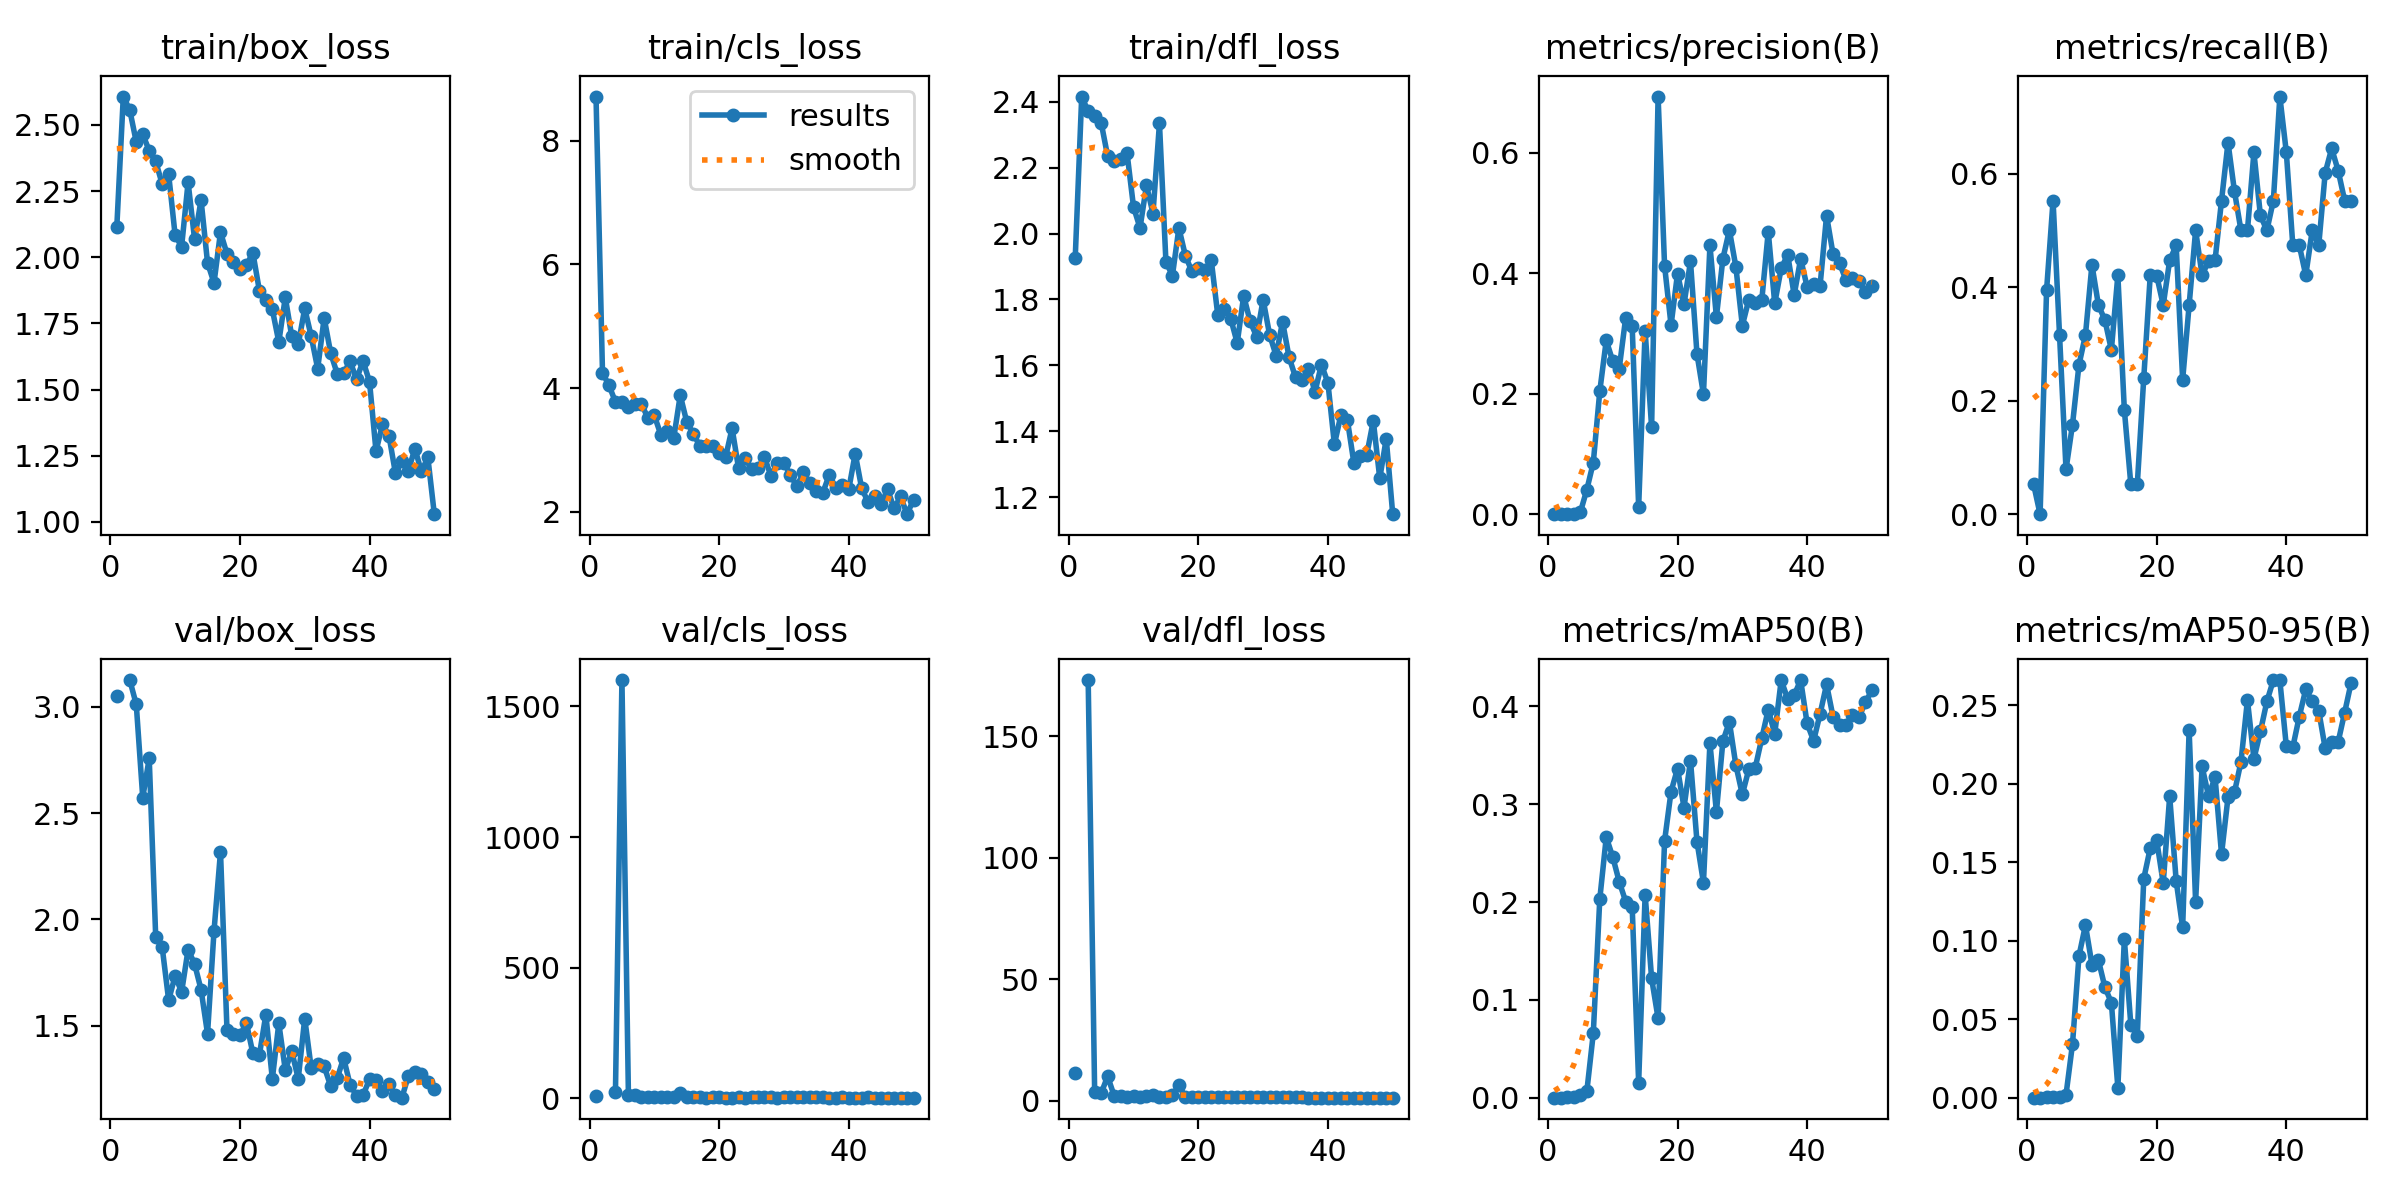


📊 Confusion Matrix


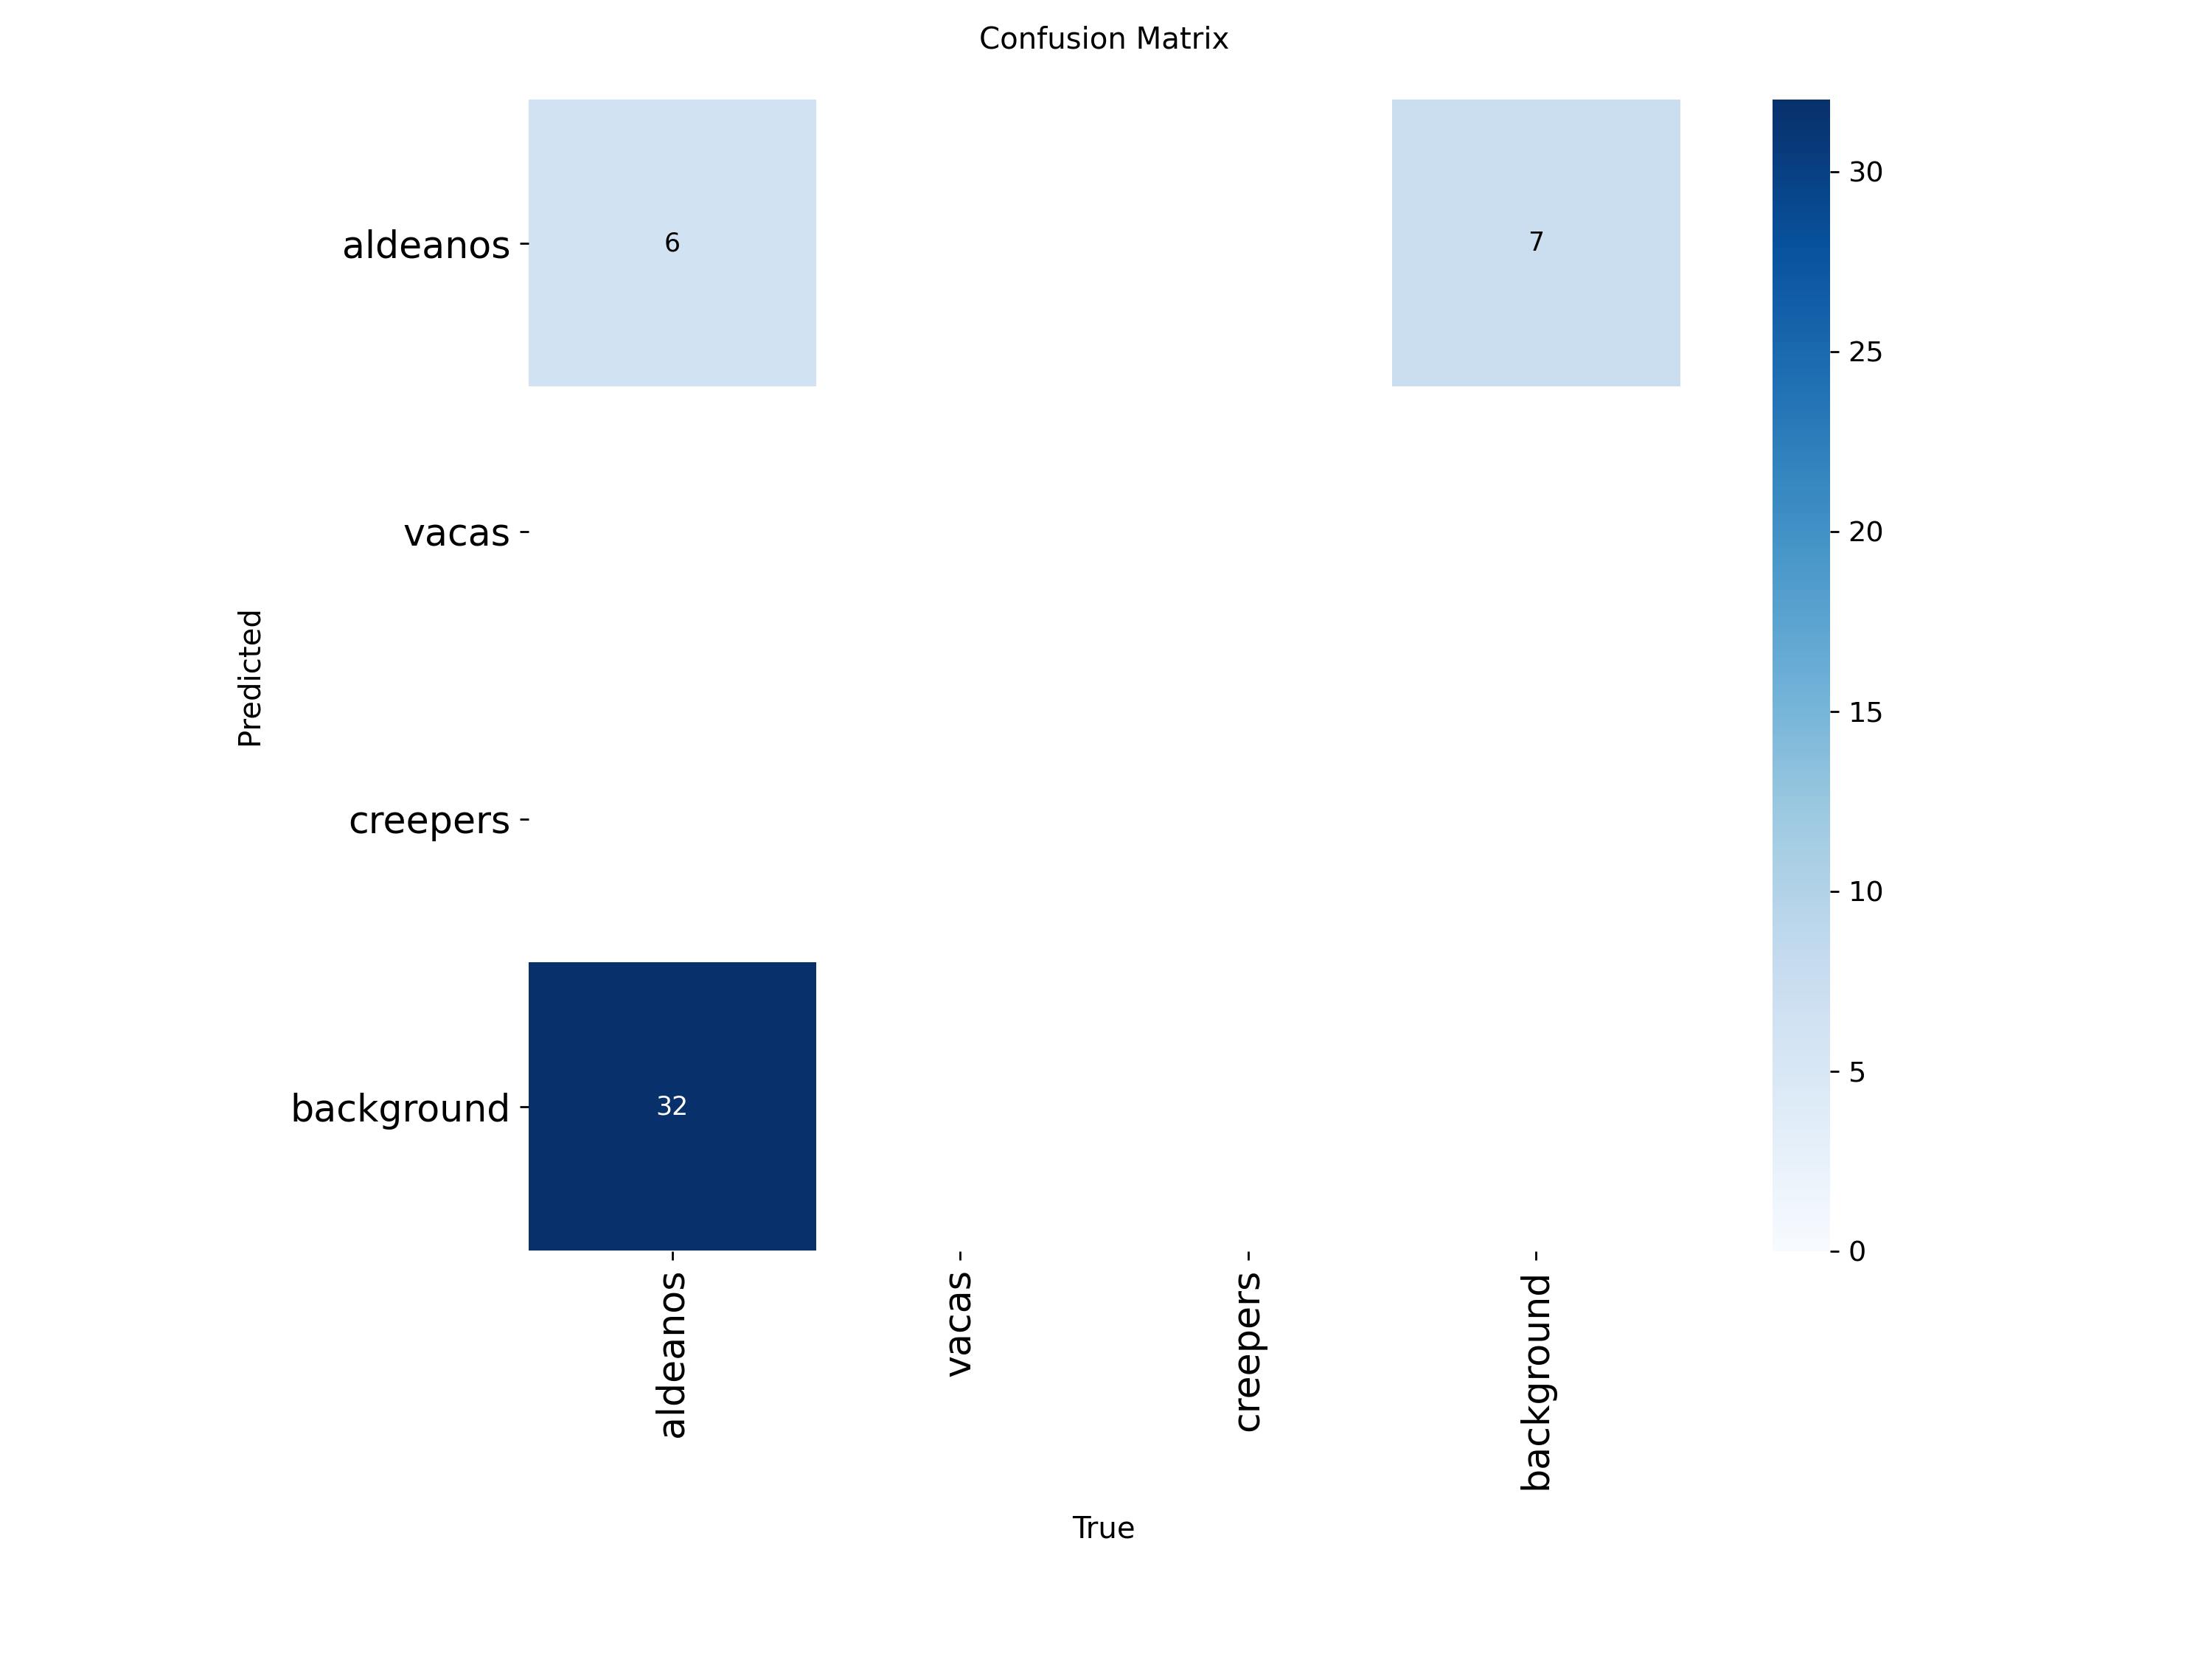


🎉 Proceso completado!
📁 Modelo guardado en: C:\Users\Usuario\Desktop\Dataset\mobs-yolo\runs\yolov8_mobs4\weights\best.pt
📊 Resultados en: C:\Users\Usuario\Desktop\Dataset\mobs-yolo\runs\yolov8_mobs4


In [11]:
# ========================
# 7️⃣ VISUALIZAR RESULTADOS
# ========================
# Usar el modelo más reciente
runs_dir = OUTPUT_DIR / 'runs'
yolo_runs = sorted(runs_dir.glob('yolov8_mobs*'), key=lambda x: x.stat().st_mtime, reverse=True)

if yolo_runs:
    results_path = yolo_runs[0]
    print(f"\n📈 Gráficas de entrenamiento generadas en: {results_path}")
    
    # Mostrar gráficas principales en el notebook
    from IPython.display import Image as IPImage, display
    
    for plot_name in ['results.png', 'confusion_matrix.png', 'F1_curve.png', 'PR_curve.png']:
        plot_path = results_path / plot_name
        if plot_path.exists():
            print(f"\n{'='*50}")
            print(f"📊 {plot_name.replace('.png', '').replace('_', ' ').title()}")
            print(f"{'='*50}")
            display(IPImage(filename=str(plot_path)))
    
    # Guardar ruta del mejor modelo
    best_model_path = results_path / 'weights/best.pt'
    
    print("\n🎉 Proceso completado!")
    print(f"📁 Modelo guardado en: {best_model_path}")
    print(f"📊 Resultados en: {results_path}")
else:
    print("⚠️ No se encontraron resultados de entrenamiento")

## ======= Prueba de modelo =======

🔮 PREDICCIÓN DE EJEMPLO EN IMÁGENES DE VALIDACIÓN

🤖 Modelo: yolov8_minecrat_mobs2
📁 Usando: best.pt

📸 Seleccionadas 5 imágenes de 636 disponibles

⏳ Ejecutando predicciones...
Results saved to C:\Users\Usuario\Desktop\Dataset\models\trained\predict_examples

✅ Predicciones guardadas en: C:\Users\Usuario\Desktop\Dataset\models\trained\predict_examples

📊 ANÁLISIS DE DETECCIONES

📷 Imagen 1: 2025-09-21_21.32.37.png
   ✅ Detectados: 1 objeto(s)
      • CREEPERS: 78.61%

📷 Imagen 2: 2025-09-21_21.15.07.png
   ✅ Detectados: 1 objeto(s)
      • CREEPERS: 83.58%

📷 Imagen 3: 2025-09-21_22.25.47.png
   ✅ Detectados: 1 objeto(s)
      • ALDEANOS: 58.03%

📷 Imagen 4: 2025-09-21_22.20.50.png
   ⚠️ No se detectaron objetos (conf > 25%)

📷 Imagen 5: 2025-09-21_22.14.57.png
   ✅ Detectados: 1 objeto(s)
      • ALDEANOS: 44.74%

📈 RESUMEN DE DETECCIONES

   Total de detecciones: 4

   Detecciones por clase:
      • CREEPERS: 2 detección(es)
      • ALDEANOS: 2 detección(es)

🖼️ VISUALIZACIÓN DE PRE

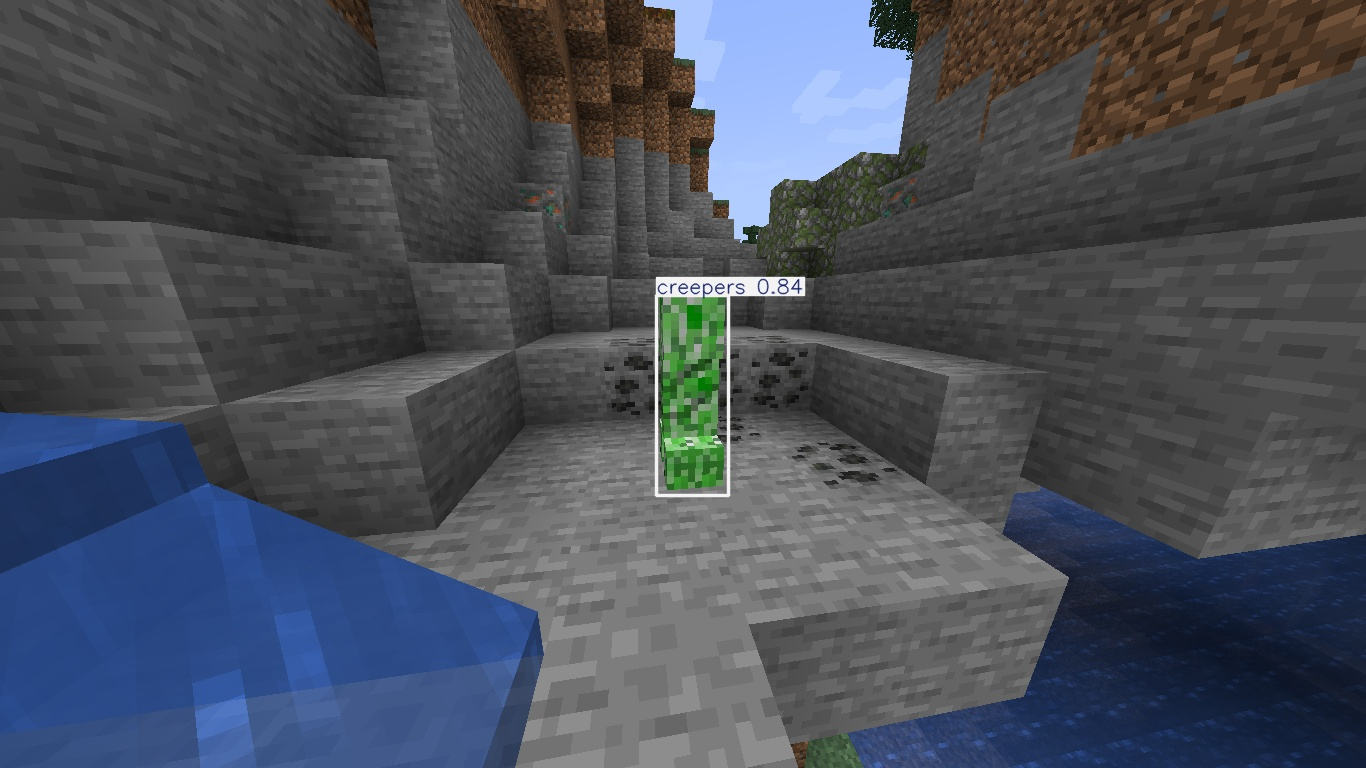


────────────────────────────────────────────────────────────
Imagen 2/5: 2025-09-21_21.32.37.jpg
────────────────────────────────────────────────────────────

🎯 Con Detecciones:


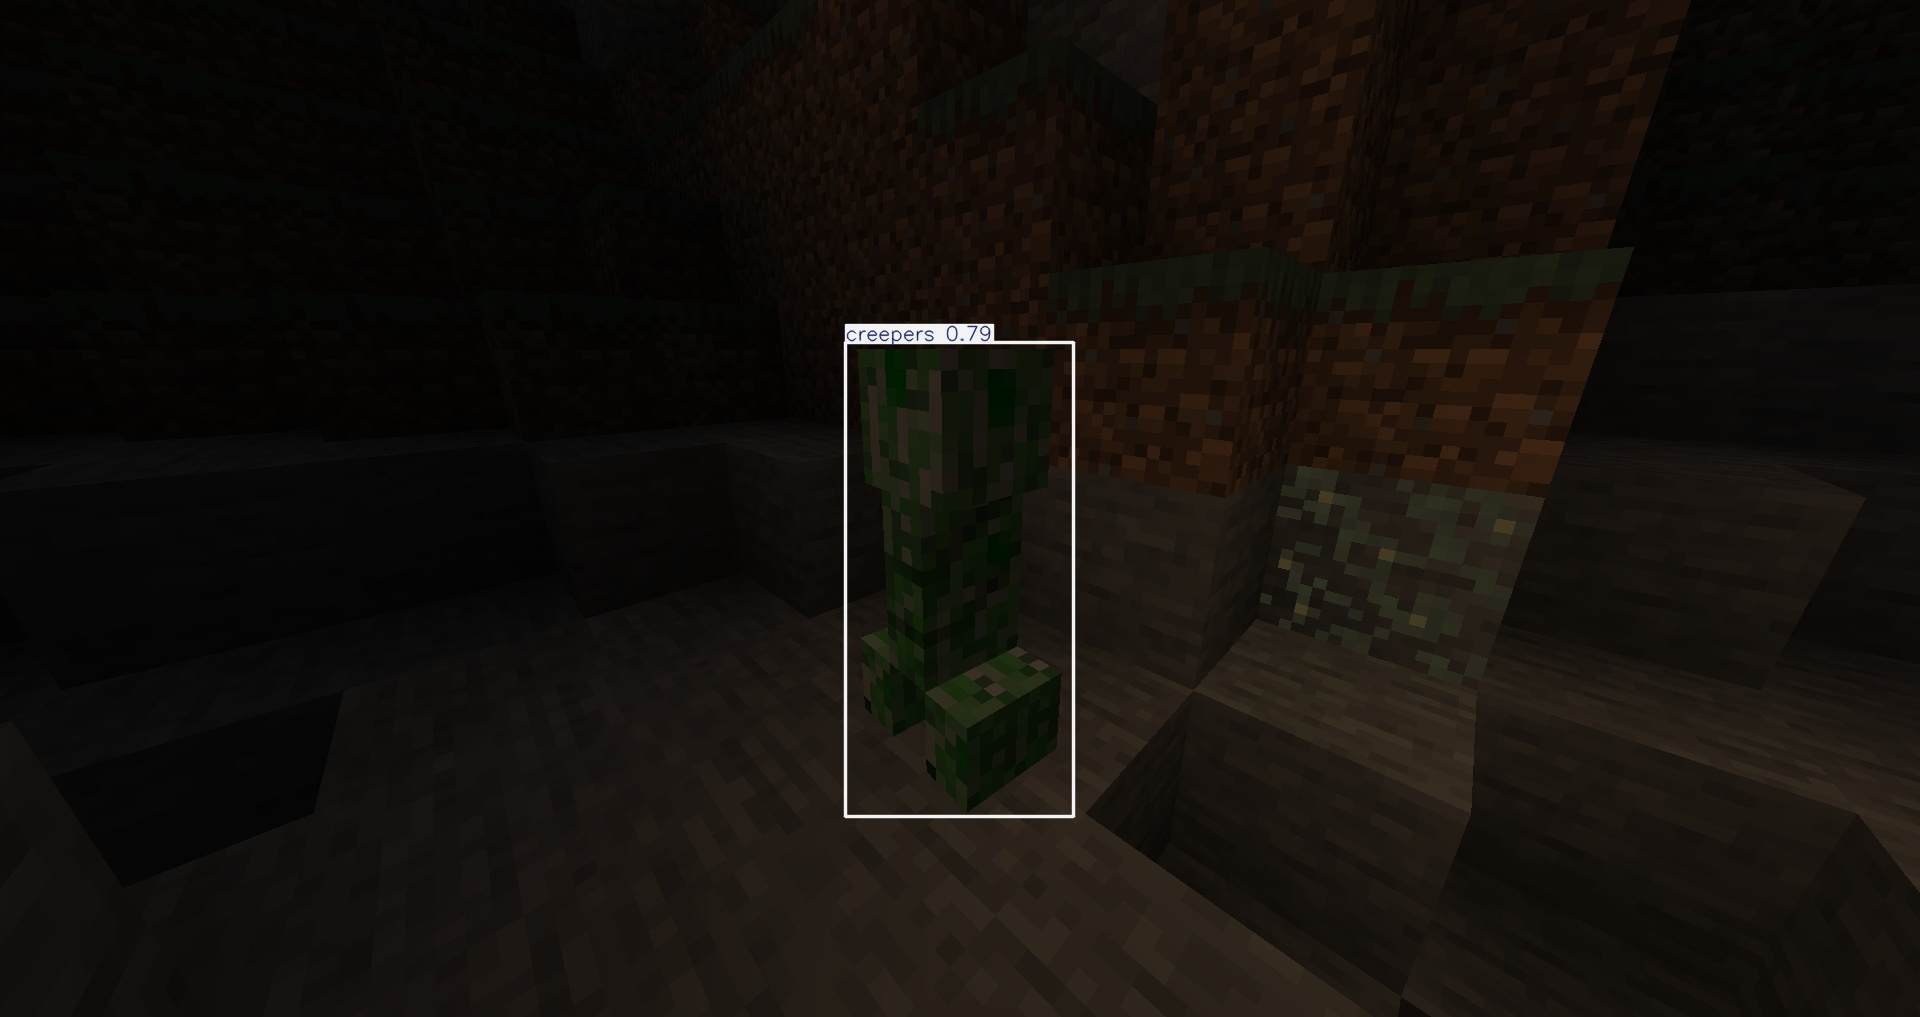


────────────────────────────────────────────────────────────
Imagen 3/5: 2025-09-21_22.14.57.jpg
────────────────────────────────────────────────────────────

🎯 Con Detecciones:


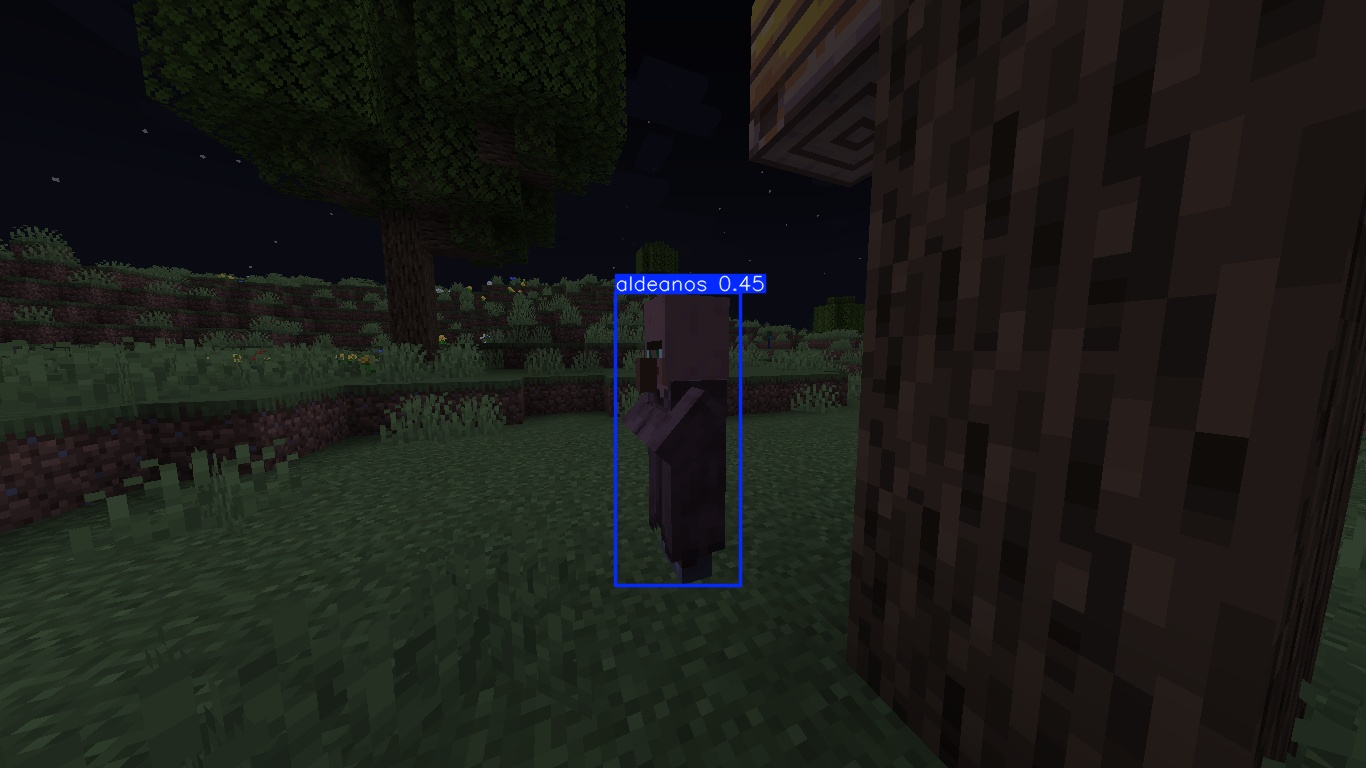


────────────────────────────────────────────────────────────
Imagen 4/5: 2025-09-21_22.20.50.jpg
────────────────────────────────────────────────────────────

🎯 Con Detecciones:


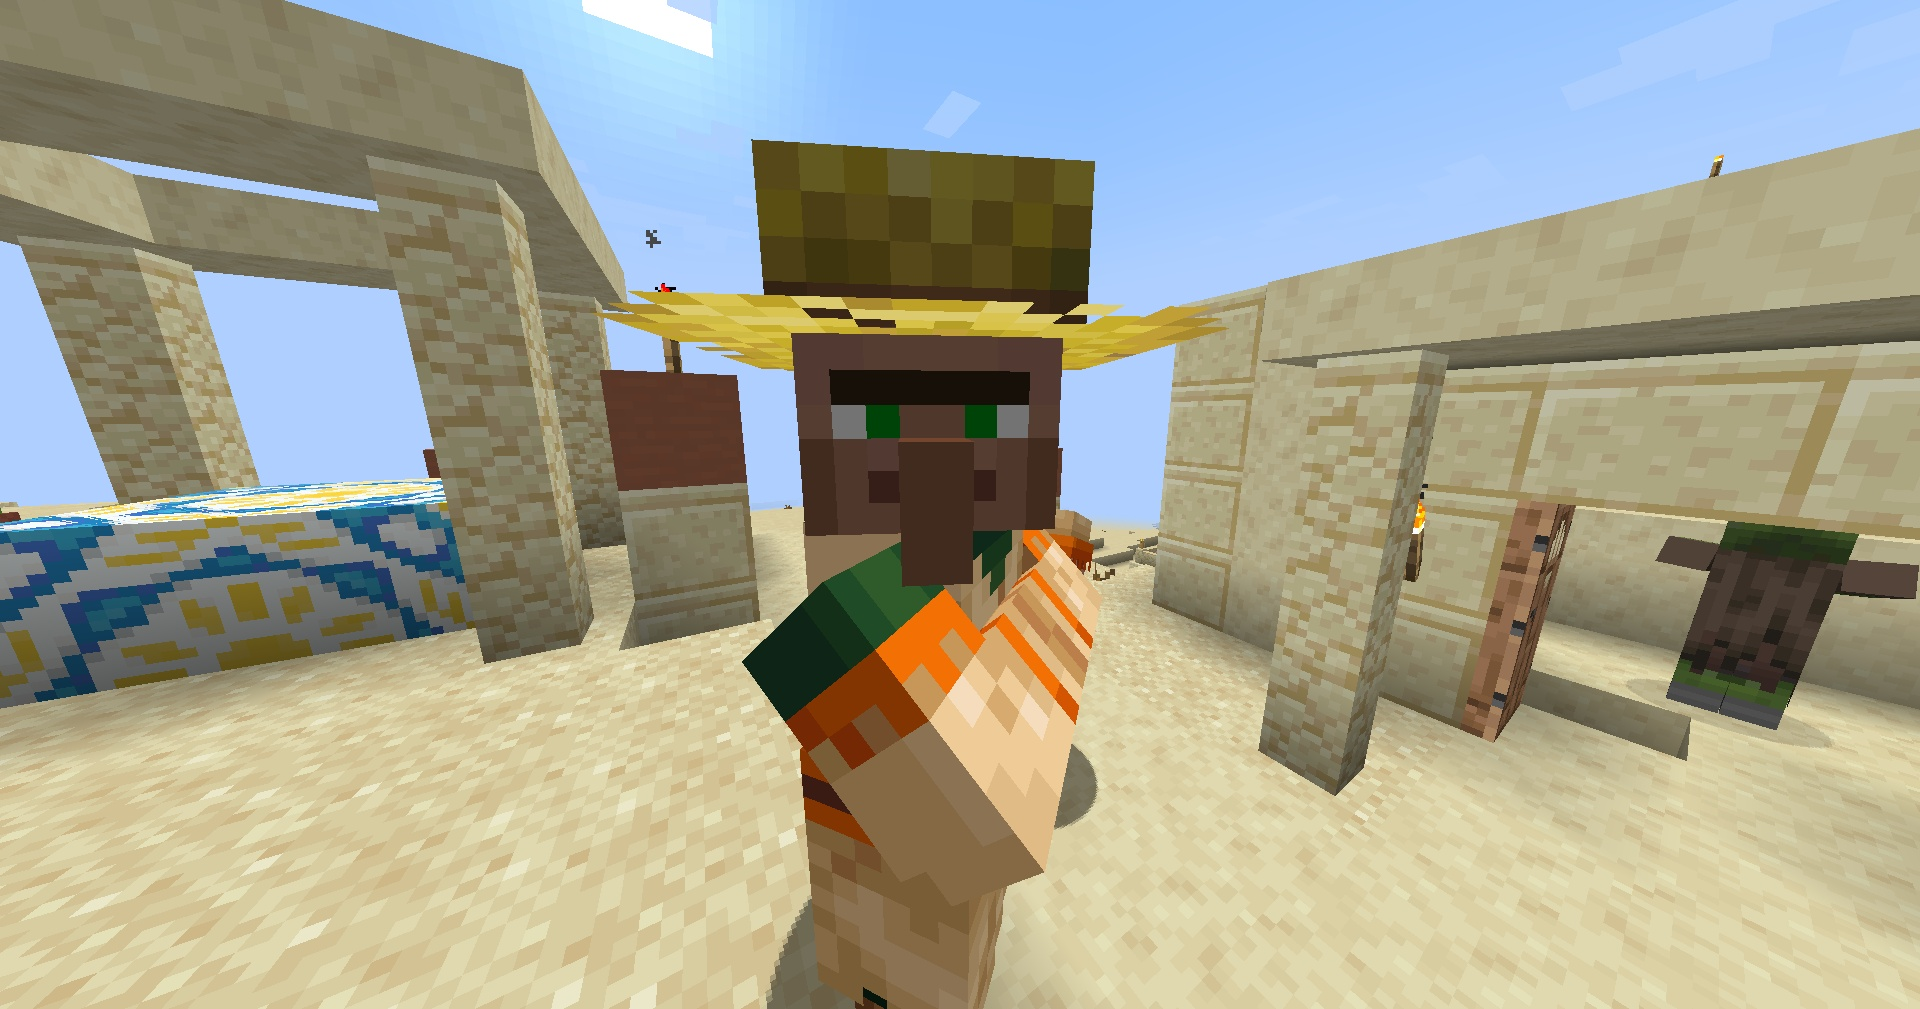


────────────────────────────────────────────────────────────
Imagen 5/5: 2025-09-21_22.25.47.jpg
────────────────────────────────────────────────────────────

🎯 Con Detecciones:


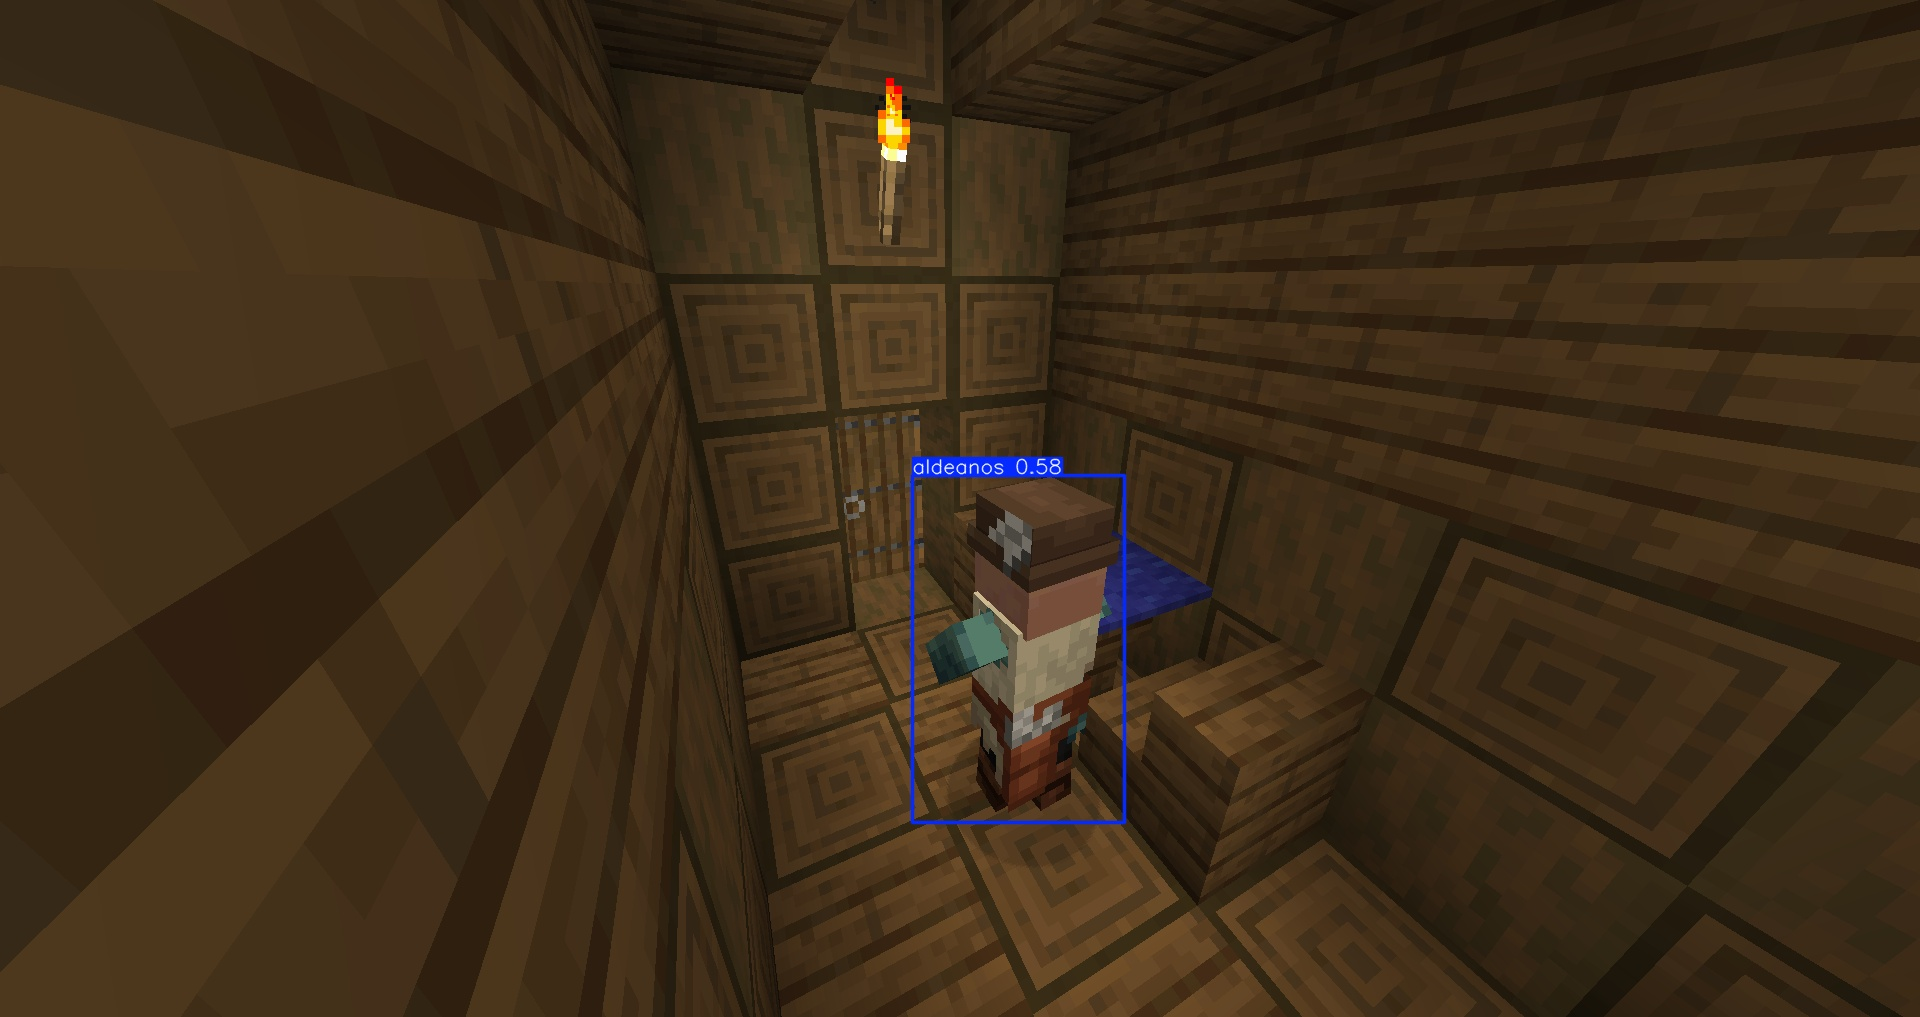


✅ PREDICCIÓN DE EJEMPLO COMPLETADA

📁 Todas las predicciones guardadas en:
   C:\Users\Usuario\Desktop\Dataset\models\trained\predict_examples


In [18]:
# ========================
# 8️⃣ PREDICCIÓN DE EJEMPLO
# ========================
from IPython.display import Image as IPImage, display
from pathlib import Path

# Buscar el último modelo entrenado
MODELS_DIR = Path(r"C:\Users\Usuario\Desktop\Dataset\models")
runs_dir = MODELS_DIR / 'trained'
yolo_runs = sorted(runs_dir.glob('yolov8_minecrat_mobs*'), key=lambda x: x.stat().st_mtime, reverse=True)

if yolo_runs:
    latest_run = yolo_runs[0]
    best_model_path = latest_run / 'weights' / 'best.pt'
    
    if best_model_path.exists():
        print("="*60)
        print("🔮 PREDICCIÓN DE EJEMPLO EN IMÁGENES DE VALIDACIÓN")
        print("="*60)
        print(f"\n🤖 Modelo: {latest_run.name}")
        print(f"📁 Usando: {best_model_path.name}")
        
        # Cargar modelo
        model = YOLO(str(best_model_path))
        
        # Obtener imágenes de validación
        val_images_dir = OUTPUT_DIR / 'images/val'
        all_val_images = list(val_images_dir.glob('*.jpg')) + \
                        list(val_images_dir.glob('*.png')) + \
                        list(val_images_dir.glob('*.jpeg'))
        
        # Seleccionar 5 imágenes aleatorias
        import random
        random.seed(42)
        val_images = random.sample(all_val_images, min(5, len(all_val_images)))
        
        print(f"\n📸 Seleccionadas {len(val_images)} imágenes de {len(all_val_images)} disponibles")
        
        if val_images:
            print(f"\n⏳ Ejecutando predicciones...")
            
            # Hacer predicciones
            predictions = model.predict(
                source=val_images,
                imgsz=IMG_SIZE,
                conf=0.25,          # Confianza mínima 25%
                iou=0.45,           # IoU threshold
                device=DEVICE,
                save=True,          # Guardar imágenes con predicciones
                project=str(MODELS_DIR / 'trained'),
                name='predict_examples',
                show_labels=True,   # Mostrar etiquetas
                show_conf=True,     # Mostrar confianza
                line_width=2,
                verbose=False       # No mostrar detalles innecesarios
            )
            
            # Buscar la carpeta de predicciones más reciente
            pred_dirs = sorted((MODELS_DIR / 'trained').glob('predict_examples*'), 
                             key=lambda x: x.stat().st_mtime, reverse=True)
            
            if pred_dirs:
                pred_dir = pred_dirs[0]
                print(f"\n✅ Predicciones guardadas en: {pred_dir}")
                
                # ========================
                # ANÁLISIS DE RESULTADOS
                # ========================
                print(f"\n{'='*60}")
                print(f"📊 ANÁLISIS DE DETECCIONES")
                print(f"{'='*60}")
                
                total_detections = 0
                detections_per_class = {}
                
                for i, (result, img_path) in enumerate(zip(predictions, val_images), 1):
                    num_boxes = len(result.boxes)
                    total_detections += num_boxes
                    
                    print(f"\n📷 Imagen {i}: {img_path.name}")
                    
                    if num_boxes > 0:
                        print(f"   ✅ Detectados: {num_boxes} objeto(s)")
                        
                        for box in result.boxes:
                            class_id = int(box.cls[0])
                            class_name = result.names[class_id]
                            confidence = float(box.conf[0])
                            
                            # Contar detecciones por clase
                            if class_name not in detections_per_class:
                                detections_per_class[class_name] = 0
                            detections_per_class[class_name] += 1
                            
                            print(f"      • {class_name.upper()}: {confidence:.2%}")
                    else:
                        print(f"   ⚠️ No se detectaron objetos (conf > 25%)")
                
                # ========================
                # RESUMEN DE DETECCIONES
                # ========================
                print(f"\n{'='*60}")
                print(f"📈 RESUMEN DE DETECCIONES")
                print(f"{'='*60}")
                print(f"\n   Total de detecciones: {total_detections}")
                
                if detections_per_class:
                    print(f"\n   Detecciones por clase:")
                    for class_name, count in sorted(detections_per_class.items(), key=lambda x: x[1], reverse=True):
                        print(f"      • {class_name.upper()}: {count} detección(es)")
                else:
                    print(f"\n   ⚠️ No se detectaron objetos en ninguna imagen")
                
                # ========================
                # MOSTRAR IMÁGENES CON PREDICCIONES
                # ========================
                print(f"\n{'='*60}")
                print(f"🖼️ VISUALIZACIÓN DE PREDICCIONES")
                print(f"{'='*60}")
                
                pred_images = sorted(pred_dir.glob('*.jpg')) + \
                             sorted(pred_dir.glob('*.png')) + \
                             sorted(pred_dir.glob('*.jpeg'))
                
                for i, img_path in enumerate(pred_images[:5], 1):
                    # Encontrar la imagen original correspondiente
                    original_name = img_path.name
                    original_img = None
                    
                    for orig in val_images:
                        if orig.name == original_name:
                            original_img = orig
                            break
                    
                    print(f"\n{'─'*60}")
                    print(f"Imagen {i}/{len(pred_images)}: {img_path.name}")
                    print(f"{'─'*60}")
                    
                    # Mostrar imagen original (pequeña)
                    if original_img and original_img.exists():
                        print(f"\n📸 Original:")
                        display(IPImage(filename=str(original_img), width=400))
                    
                    # Mostrar imagen con predicciones (grande)
                    print(f"\n🎯 Con Detecciones:")
                    display(IPImage(filename=str(img_path), width=800))
                
                print(f"\n{'='*60}")
                print(f"✅ PREDICCIÓN DE EJEMPLO COMPLETADA")
                print(f"{'='*60}")
                print(f"\n📁 Todas las predicciones guardadas en:")
                print(f"   {pred_dir}")
            else:
                print(f"\n⚠️ No se encontró la carpeta de predicciones")
        else:
            print(f"\n⚠️ No se encontraron imágenes de validación en:")
            print(f"   {val_images_dir}")
    else:
        print(f"\n⚠️ No se encontró best.pt en {latest_run.name}")
        print(f"   Verifica que el entrenamiento haya finalizado correctamente")
else:
    print("="*60)
    print("⚠️ NO SE ENCONTRÓ NINGÚN MODELO ENTRENADO")
    print("="*60)
    print(f"\n📁 Buscado en: {runs_dir}")
    print(f"\n💡 Soluciones:")
    print(f"   1. Ejecuta primero la celda de entrenamiento (#5)")
    print(f"   2. Verifica que MODELS_DIR sea correcto:")
    print(f"      {MODELS_DIR}")
    print(f"   3. Revisa que exista la carpeta 'trained/'")

---
## 🎯 Predicción con imagen personalizada

Usa la siguiente celda para clasificar cualquier imagen que quieras.

🎨 PREDICCIÓN CON IMAGEN PERSONALIZADA

📸 Imagen seleccionada: C:\Users\Usuario\Desktop\Dataset\Imagenes_prueba\2025-11-03_13.04.36.png

🤖 Modelo: yolov8_minecrat_mobs2
📊 Usando: best.pt

⏳ Analizando imagen...
Results saved to C:\Users\Usuario\Desktop\Dataset\models\trained\predict_custom5

✅ RESULTADOS DE LA PREDICCIÓN

🎯 Se detectaron 3 objeto(s):

────────────────────────────────────────────────────────────
📊 RESUMEN POR CLASE
────────────────────────────────────────────────────────────

   🏷️ ALDEANOS: 1 detección(es)
      Confianza promedio: 30.54%

   🏷️ CREEPERS: 1 detección(es)
      Confianza promedio: 65.45%

   🏷️ VACAS: 1 detección(es)
      Confianza promedio: 82.97%

────────────────────────────────────────────────────────────
🔍 DETECCIONES INDIVIDUALES
────────────────────────────────────────────────────────────

   1. VACAS ✅
      Confianza: 82.97% (Seguro)
      Coordenadas (x1, y1, x2, y2):
         [307.2, 391.8, 607.8, 695.6]

   2. CREEPERS 👍
      Confianza: 65.

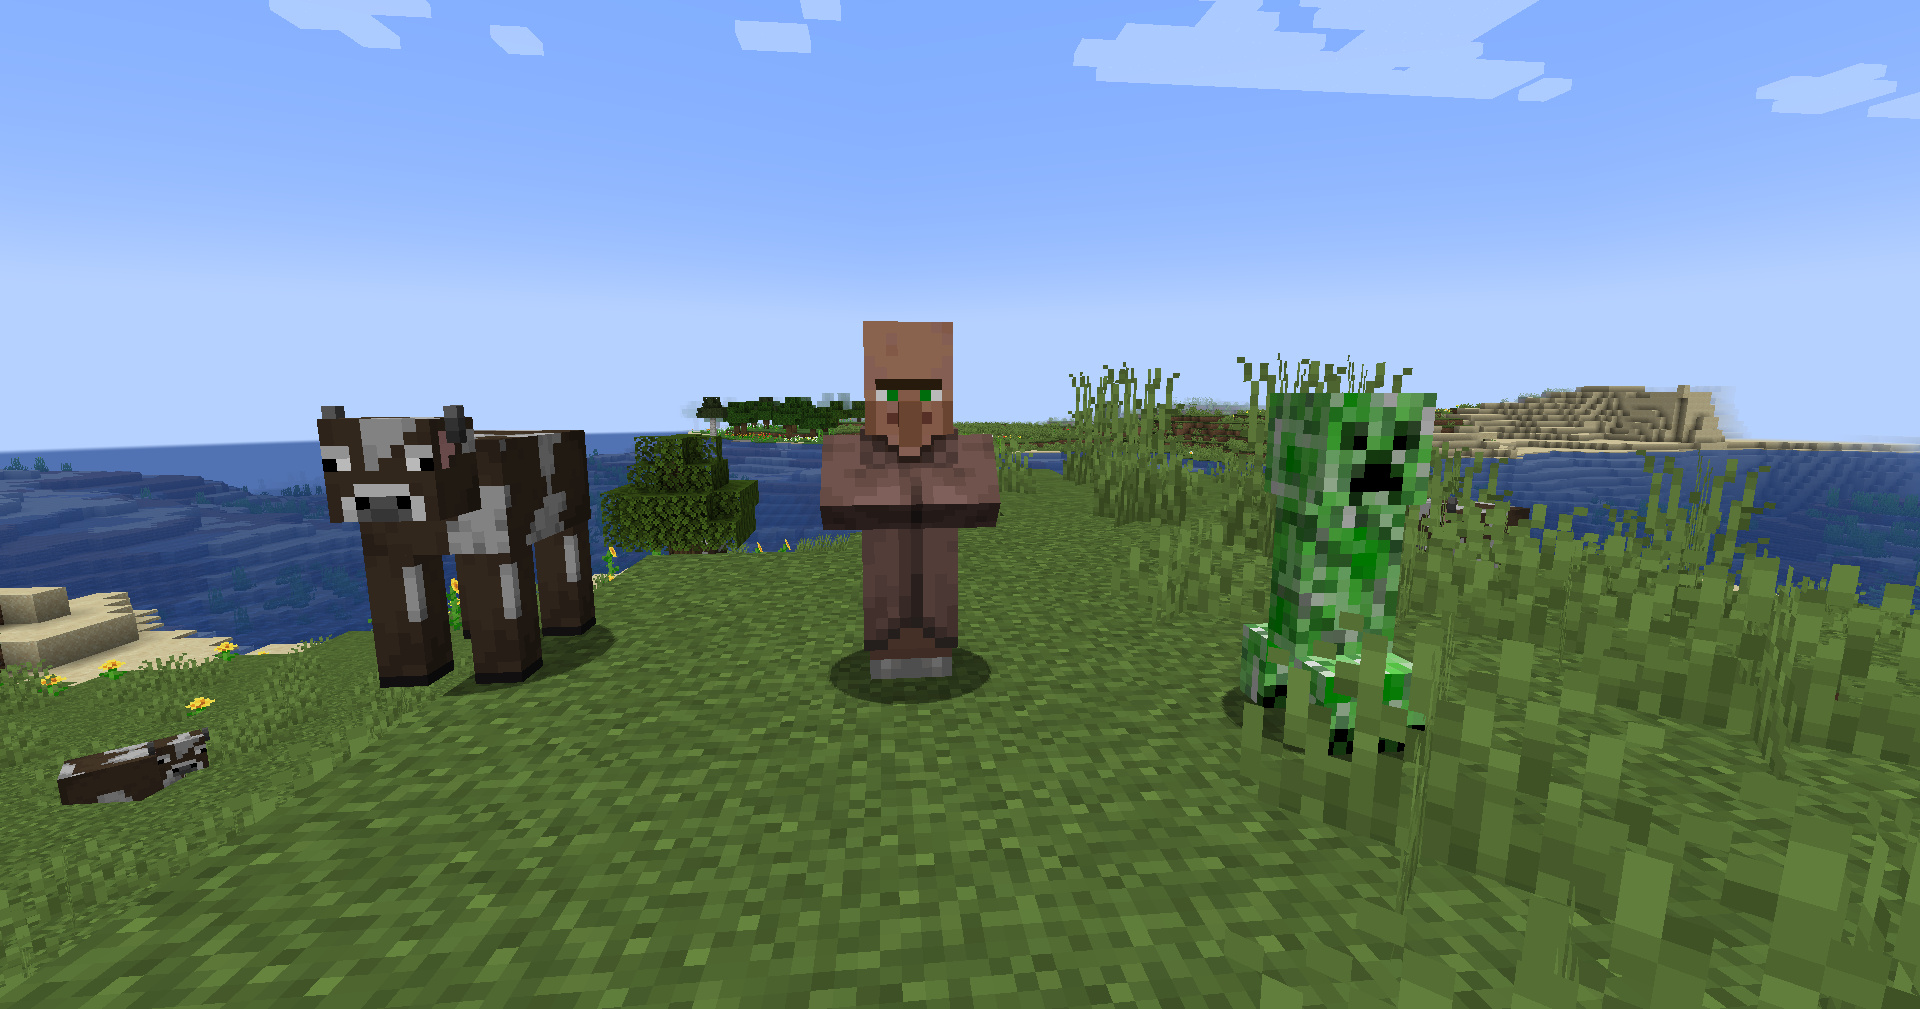


🎯 IMAGEN CON DETECCIONES
────────────────────────────────────────────────────────────


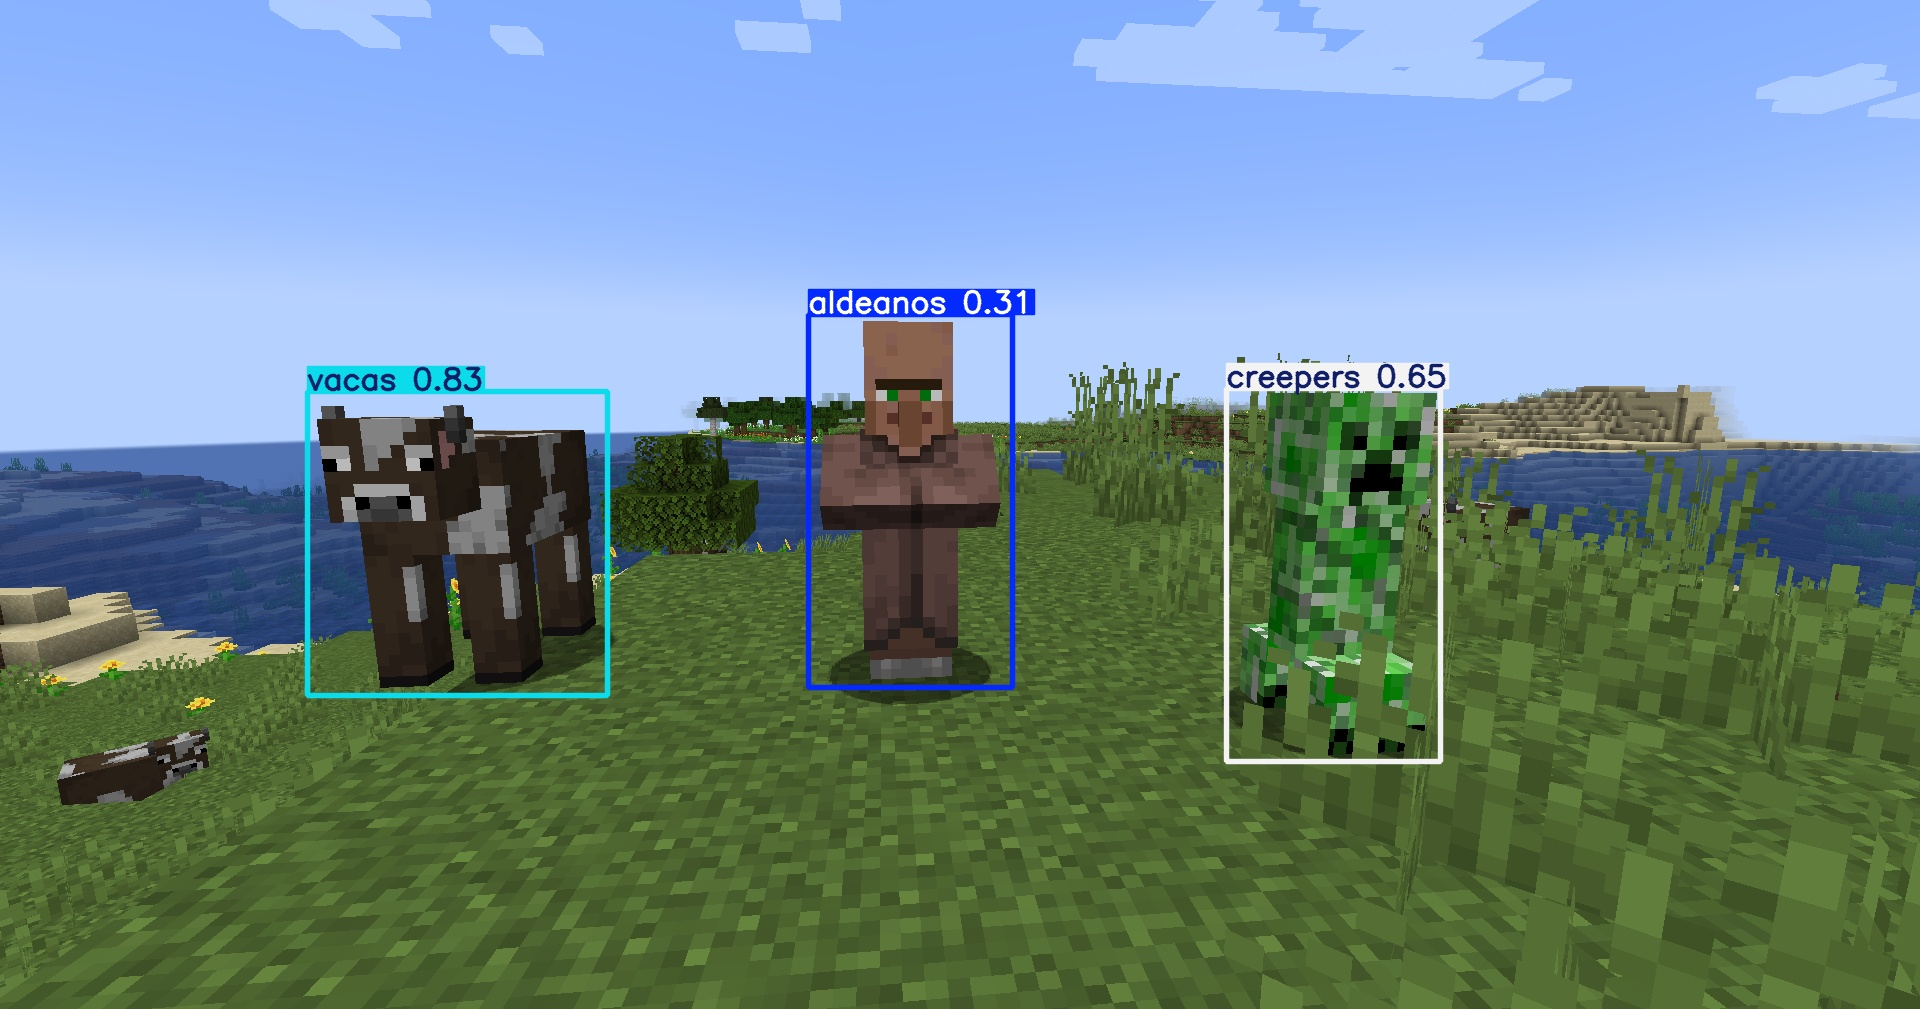


✅ PREDICCIÓN COMPLETADA

📁 Imagen guardada en:
   C:\Users\Usuario\Desktop\Dataset\models\trained\predict_custom5\2025-11-03_13.04.36.jpg


In [25]:
# ========================
# 9️⃣ PREDICCIÓN CON IMAGEN PERSONALIZADA
# ========================
from IPython.display import Image as IPImage, display
from pathlib import Path

# 📌 CONFIGURA AQUÍ LA RUTA DE TU IMAGEN
# Puedes usar rutas absolutas o relativas
IMAGEN_A_CLASIFICAR = r"C:\Users\Usuario\Desktop\Dataset\Imagenes_prueba\2025-11-03_13.04.36.png"

# También puedes probar con estas:
# IMAGEN_A_CLASIFICAR = r"C:\ruta\a\tu\imagen.png"
# IMAGEN_A_CLASIFICAR = "imagen_en_carpeta_actual.jpg"

print("="*60)
print("🎨 PREDICCIÓN CON IMAGEN PERSONALIZADA")
print("="*60)
print(f"\n📸 Imagen seleccionada: {IMAGEN_A_CLASIFICAR}")

# Verificar que existe la imagen
img_path = Path(IMAGEN_A_CLASIFICAR)

if not img_path.exists():
    print(f"\n❌ ERROR: No se encuentra la imagen en:")
    print(f"   {img_path}")
    print(f"\n💡 Soluciones:")
    print(f"   1. Verifica que la ruta sea correcta")
    print(f"   2. Usa rutas absolutas (ejemplo: r'C:\\Users\\...')")
    print(f"   3. O coloca la imagen en: C:\\Users\\Usuario\\Desktop\\Dataset\\Imagenes_prueba\\")
else:
    # Buscar el último modelo entrenado
    MODELS_DIR = Path(r"C:\Users\Usuario\Desktop\Dataset\models")
    runs_dir = MODELS_DIR / 'trained'
    yolo_runs = sorted(runs_dir.glob('yolov8_minecrat_mobs*'), 
                      key=lambda x: x.stat().st_mtime, reverse=True)
    
    if yolo_runs:
        latest_run = yolo_runs[0]
        best_model_path = latest_run / 'weights' / 'best.pt'
        
        if best_model_path.exists():
            print(f"\n🤖 Modelo: {latest_run.name}")
            print(f"📊 Usando: {best_model_path.name}")
            
            # Cargar modelo
            model = YOLO(str(best_model_path))
            
            # Hacer predicción
            print(f"\n⏳ Analizando imagen...")
            results = model.predict(
                source=str(img_path),
                imgsz=IMG_SIZE,
                conf=0.25,          # Confianza mínima 25%
                iou=0.45,           # IoU threshold
                device=DEVICE,
                save=True,          # Guardar imagen con predicciones
                project=str(MODELS_DIR / 'trained'),
                name='predict_custom',
                show_labels=True,   # Mostrar etiquetas
                show_conf=True,     # Mostrar confianza
                line_width=3,       # Líneas más gruesas
                verbose=False       # No mostrar detalles innecesarios
            )
            
            # Obtener resultados
            result = results[0]
            
            # ========================
            # RESULTADOS DETALLADOS
            # ========================
            print(f"\n{'='*60}")
            print(f"✅ RESULTADOS DE LA PREDICCIÓN")
            print(f"{'='*60}")
            
            # Verificar si se detectó algo
            if len(result.boxes) > 0:
                print(f"\n🎯 Se detectaron {len(result.boxes)} objeto(s):\n")
                
                # Agrupar detecciones por clase
                detections_by_class = {}
                
                for box in result.boxes:
                    class_id = int(box.cls[0])
                    class_name = result.names[class_id]
                    confidence = float(box.conf[0])
                    coords = box.xyxy[0].tolist()
                    
                    if class_name not in detections_by_class:
                        detections_by_class[class_name] = []
                    
                    detections_by_class[class_name].append({
                        'confidence': confidence,
                        'coords': coords
                    })
                
                # Mostrar resumen por clase
                print(f"{'─'*60}")
                print(f"📊 RESUMEN POR CLASE")
                print(f"{'─'*60}\n")
                
                for class_name, detections in sorted(detections_by_class.items()):
                    print(f"   🏷️ {class_name.upper()}: {len(detections)} detección(es)")
                    avg_conf = sum(d['confidence'] for d in detections) / len(detections)
                    print(f"      Confianza promedio: {avg_conf:.2%}\n")
                
                # Mostrar detecciones individuales
                print(f"{'─'*60}")
                print(f"🔍 DETECCIONES INDIVIDUALES")
                print(f"{'─'*60}\n")
                
                for i, box in enumerate(result.boxes, 1):
                    class_id = int(box.cls[0])
                    class_name = result.names[class_id]
                    confidence = float(box.conf[0])
                    coords = box.xyxy[0].tolist()
                    
                    # Emoji según confianza
                    if confidence >= 0.90:
                        conf_emoji = "🌟"
                        conf_status = "Muy seguro"
                    elif confidence >= 0.75:
                        conf_emoji = "✅"
                        conf_status = "Seguro"
                    elif confidence >= 0.50:
                        conf_emoji = "👍"
                        conf_status = "Moderado"
                    else:
                        conf_emoji = "⚠️"
                        conf_status = "Bajo"
                    
                    print(f"   {i}. {class_name.upper()} {conf_emoji}")
                    print(f"      Confianza: {confidence:.2%} ({conf_status})")
                    print(f"      Coordenadas (x1, y1, x2, y2):")
                    print(f"         [{coords[0]:.1f}, {coords[1]:.1f}, {coords[2]:.1f}, {coords[3]:.1f}]")
                    print()
                
            else:
                print(f"\n⚠️ No se detectaron objetos en la imagen")
                print(f"   (con confianza mínima de 25%)")
                print(f"\n💡 Sugerencias:")
                print(f"   • Prueba con otra imagen que tenga mobs más visibles")
                print(f"   • Verifica que la imagen sea de Minecraft")
                print(f"   • Los mobs entrenados son: aldeanos, creepers, vacas")
            
            # ========================
            # VISUALIZACIÓN
            # ========================
            # Buscar la carpeta de predicciones más reciente
            pred_dirs = sorted((MODELS_DIR / 'trained').glob('predict_custom*'), 
                             key=lambda x: x.stat().st_mtime, reverse=True)
            
            if pred_dirs:
                pred_dir = pred_dirs[0]
                pred_images = list(pred_dir.glob('*.jpg')) + \
                             list(pred_dir.glob('*.png')) + \
                             list(pred_dir.glob('*.jpeg'))
                
                if pred_images:
                    result_img = pred_images[0]
                    
                    print(f"\n{'='*60}")
                    print(f"🖼️ VISUALIZACIÓN")
                    print(f"{'='*60}")
                    
                    print(f"\n📸 IMAGEN ORIGINAL")
                    print(f"{'─'*60}")
                    display(IPImage(filename=str(img_path), width=600))
                    
                    print(f"\n🎯 IMAGEN CON DETECCIONES")
                    print(f"{'─'*60}")
                    display(IPImage(filename=str(result_img), width=800))
                    
                    print(f"\n{'='*60}")
                    print(f"✅ PREDICCIÓN COMPLETADA")
                    print(f"{'='*60}")
                    print(f"\n📁 Imagen guardada en:")
                    print(f"   {result_img}")
            else:
                print(f"\n⚠️ No se pudo guardar la imagen con predicciones")
        else:
            print(f"\n⚠️ No se encontró best.pt en {latest_run.name}")
            print(f"   Verifica que el entrenamiento haya finalizado correctamente")
    else:
        print("="*60)
        print("⚠️ NO SE ENCONTRÓ NINGÚN MODELO ENTRENADO")
        print("="*60)
        print(f"\n📁 Buscado en: {runs_dir}")
        print(f"\n💡 Soluciones:")
        print(f"   1. Ejecuta primero la celda de entrenamiento (#5)")
        print(f"   2. Ejecuta la celda de validación (#6)")
        print(f"   3. Verifica que exista la carpeta 'trained/'")

In [5]:
# ========================
# 1️⃣1️⃣ PREDICCIÓN EN TIEMPO REAL (WEBCAM)
# ========================
import cv2
from pathlib import Path
from ultralytics import YOLO

print("="*60)
print("📹 PREDICCIÓN EN TIEMPO REAL (WEBCAM)")
print("="*60)
print(f"\n⚠️ ADVERTENCIA:")
print(f"   Esta celda abrirá una ventana de CV2")
print(f"   Presiona 'q' para SALIR")
print(f"   Presiona 's' para guardar un SCREENSHOT")

# Buscar el último modelo entrenado
MODELS_DIR = Path(r"C:\Users\Usuario\Desktop\Dataset\models")
runs_dir = MODELS_DIR / 'trained'
yolo_runs = sorted(runs_dir.glob('yolov8_minecrat_mobs*'), 
                  key=lambda x: x.stat().st_mtime, reverse=True)

if yolo_runs:
    latest_run = yolo_runs[0]
    best_model_path = latest_run / 'weights' / 'best.pt'
    
    if best_model_path.exists():
        print(f"\n🤖 Modelo: {latest_run.name}")
        print(f"📊 Usando: {best_model_path.name}")
        
        # Cargar modelo
        model = YOLO(str(best_model_path))
        
        # Configuración de webcam
        # Cambia a 1, 2, etc. si tienes múltiples cámaras
        CAMERA_ID = 0  
        
        print(f"\n📹 Intentando abrir cámara {CAMERA_ID}...")
        cap = cv2.VideoCapture(CAMERA_ID)
        
        if not cap.isOpened():
            print(f"❌ ERROR: No se pudo abrir la cámara")
            print(f"\n💡 Soluciones:")
            print(f"   1. Verifica que la webcam esté conectada")
            print(f"   2. Cierra otras apps que usen la cámara (Zoom, Teams, etc.)")
            print(f"   3. Cambia CAMERA_ID a 1 o 2 si tienes múltiples cámaras")
        else:
            print(f"✅ Cámara abierta exitosamente")
            print(f"\n🎮 CONTROLES:")
            print(f"   'q' → Salir")
            print(f"   's' → Guardar screenshot")
            
            # Crear carpeta para screenshots
            screenshots_dir = MODELS_DIR / 'trained' / 'webcam_screenshots'
            screenshots_dir.mkdir(exist_ok=True)
            
            frame_count = 0
            screenshot_count = 0
            
            print(f"\n🚀 Iniciando detección en tiempo real...")
            print(f"   (Presiona 'q' en la ventana para salir)")
            
            while True:
                ret, frame = cap.read()
                
                if not ret:
                    print(f"⚠️ Error al leer frame de la cámara")
                    break
                
                frame_count += 1
                
                # Hacer predicción (cada frame)
                results = model.predict(
                    source=frame,
                    imgsz=640,
                    conf=0.25,
                    iou=0.45,
                    device=DEVICE,
                    verbose=False,
                    stream=False
                )
                
                # Obtener frame con detecciones
                annotated_frame = results[0].plot()
                
                # Agregar información en pantalla
                fps = cap.get(cv2.CAP_PROP_FPS)
                num_detections = len(results[0].boxes)
                
                cv2.putText(annotated_frame, f"FPS: {fps:.1f}", (10, 30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(annotated_frame, f"Detecciones: {num_detections}", (10, 70), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(annotated_frame, "Presiona 'q' para salir | 's' para screenshot", (10, 110), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
                
                # Mostrar frame
                cv2.imshow('YOLOv8 - Detección en Tiempo Real', annotated_frame)
                
                # Manejar teclas
                key = cv2.waitKey(1) & 0xFF
                
                if key == ord('q'):
                    print(f"\n🛑 Deteniendo detección...")
                    break
                elif key == ord('s'):
                    screenshot_count += 1
                    screenshot_path = screenshots_dir / f"screenshot_{screenshot_count:04d}.jpg"
                    cv2.imwrite(str(screenshot_path), annotated_frame)
                    print(f"📸 Screenshot guardado: {screenshot_path.name}")
            
            # Liberar recursos
            cap.release()
            cv2.destroyAllWindows()
            
            print(f"\n{'='*60}")
            print(f"✅ DETECCIÓN EN TIEMPO REAL FINALIZADA")
            print(f"{'='*60}")
            print(f"\n📊 Estadísticas:")
            print(f"   Frames procesados: {frame_count}")
            print(f"   Screenshots guardados: {screenshot_count}")
            
            if screenshot_count > 0:
                print(f"\n📁 Screenshots guardados en:")
                print(f"   {screenshots_dir}")
    else:
        print(f"\n⚠️ No se encontró best.pt")
else:
    print("⚠️ NO SE ENCONTRÓ NINGÚN MODELO ENTRENADO")

📹 PREDICCIÓN EN TIEMPO REAL (WEBCAM)

⚠️ ADVERTENCIA:
   Esta celda abrirá una ventana de CV2
   Presiona 'q' para SALIR
   Presiona 's' para guardar un SCREENSHOT

🤖 Modelo: yolov8_minecrat_mobs2
📊 Usando: best.pt

📹 Intentando abrir cámara 0...
✅ Cámara abierta exitosamente

🎮 CONTROLES:
   'q' → Salir
   's' → Guardar screenshot

🚀 Iniciando detección en tiempo real...
   (Presiona 'q' en la ventana para salir)


KeyboardInterrupt: 

In [29]:
%pip install mss

  Using cached mss-10.1.0-py3-none-any.whl.metadata (6.7 kB)
Using cached mss-10.1.0-py3-none-any.whl (24 kB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ========================
# 1️⃣2️⃣ PREDICCIÓN EN MINECRAFT (CAPTURA DE PANTALLA)
# ========================
import cv2
import numpy as np
from pathlib import Path
import mss
import time
from ultralytics import YOLO  # ⭐ AGREGADO

print("="*60)
print("🎮 PREDICCIÓN DIRECTO EN MINECRAFT")
print("="*60)
print(f"\n⚠️ REQUISITOS:")
print(f"   1. Minecraft abierto en modo VENTANA (no pantalla completa)")
print(f"   2. Librería 'mss' instalada: pip install mss")
print(f"\n🎮 CONTROLES:")
print(f"   Presiona 'q' para SALIR")
print(f"   Presiona 's' para guardar SCREENSHOT")

# Buscar el último modelo entrenado
MODELS_DIR = Path(r"C:\Users\Usuario\Desktop\Dataset\models")
runs_dir = MODELS_DIR / 'trained'
yolo_runs = sorted(runs_dir.glob('yolov8_minecrat_mobs*'), 
                  key=lambda x: x.stat().st_mtime, reverse=True)

if yolo_runs:
    latest_run = yolo_runs[0]
    best_model_path = latest_run / 'weights' / 'best.pt'
    
    if best_model_path.exists():
        print(f"\n🤖 Modelo: {latest_run.name}")
        print(f"📊 Usando: {best_model_path.name}")
        
        # Cargar modelo
        model = YOLO(str(best_model_path))
        
        print(f"\n⏳ Esperando 3 segundos...")
        print(f"   Abre Minecraft y déjalo visible")
        time.sleep(3)
        
        # Configurar captura de pantalla
        sct = mss.mss()
        
        # Capturar TODO el monitor principal
        # Puedes ajustar estas coordenadas para capturar solo la ventana de Minecraft
        monitor = sct.monitors[1]  # Monitor principal
        
        # 🎯 OPCIONAL: Capturar solo una región específica
        # monitor = {"top": 100, "left": 100, "width": 1280, "height": 720}
        
        print(f"\n✅ Capturando región:")
        print(f"   Top: {monitor['top']}, Left: {monitor['left']}")
        print(f"   Ancho: {monitor['width']}, Alto: {monitor['height']}")
        
        # Crear carpeta para screenshots
        screenshots_dir = MODELS_DIR / 'trained' / 'minecraft_screenshots'
        screenshots_dir.mkdir(exist_ok=True)
        
        frame_count = 0
        screenshot_count = 0
        
        print(f"\n🚀 Iniciando detección en Minecraft...")
        print(f"   (Presiona 'q' en la ventana para salir)")
        
        try:
            while True:
                # Capturar pantalla
                screenshot = sct.grab(monitor)
                
                # Convertir a formato OpenCV (BGR)
                frame = np.array(screenshot)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGRA2BGR)
                
                frame_count += 1
                
                # Hacer predicción
                results = model.predict(
                    source=frame,
                    imgsz=640,
                    conf=0.25,
                    iou=0.45,
                    device=DEVICE,
                    verbose=False,
                    stream=False
                )
                
                # Obtener frame con detecciones
                annotated_frame = results[0].plot()
                
                # Calcular FPS
                num_detections = len(results[0].boxes)
                
                # Agregar información
                cv2.putText(annotated_frame, f"Minecraft - YOLOv8 Detección", (10, 30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(annotated_frame, f"Detecciones: {num_detections}", (10, 70), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(annotated_frame, "Presiona 'q' para salir | 's' para screenshot", (10, 110), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
                
                # Mostrar detecciones por clase
                if num_detections > 0:
                    y_offset = 150
                    detections_by_class = {}
                    
                    for box in results[0].boxes:
                        class_id = int(box.cls[0])
                        class_name = results[0].names[class_id]
                        
                        if class_name not in detections_by_class:
                            detections_by_class[class_name] = 0
                        detections_by_class[class_name] += 1
                    
                    for class_name, count in detections_by_class.items():
                        cv2.putText(annotated_frame, f"{class_name.upper()}: {count}", (10, y_offset), 
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)
                        y_offset += 40
                
                # Redimensionar si es muy grande
                height, width = annotated_frame.shape[:2]
                if width > 1280:
                    scale = 1280 / width
                    new_width = int(width * scale)
                    new_height = int(height * scale)
                    annotated_frame = cv2.resize(annotated_frame, (new_width, new_height))
                
                # Mostrar frame
                cv2.imshow('YOLOv8 - Minecraft Detección en Tiempo Real', annotated_frame)
                
                # Manejar teclas
                key = cv2.waitKey(1) & 0xFF
                
                if key == ord('q'):
                    print(f"\n🛑 Deteniendo detección...")
                    break
                elif key == ord('s'):
                    screenshot_count += 1
                    screenshot_path = screenshots_dir / f"minecraft_screenshot_{screenshot_count:04d}.jpg"
                    cv2.imwrite(str(screenshot_path), annotated_frame)
                    print(f"📸 Screenshot guardado: {screenshot_path.name}")
        
        except KeyboardInterrupt:
            print(f"\n🛑 Detenido por el usuario")
        
        finally:
            # Liberar recursos
            cv2.destroyAllWindows()
            
            print(f"\n{'='*60}")
            print(f"✅ DETECCIÓN EN MINECRAFT FINALIZADA")
            print(f"{'='*60}")
            print(f"\n📊 Estadísticas:")
            print(f"   Frames procesados: {frame_count}")
            print(f"   Screenshots guardados: {screenshot_count}")
            
            if screenshot_count > 0:
                print(f"\n📁 Screenshots guardados en:")
                print(f"   {screenshots_dir}")
    else:
        print(f"\n⚠️ No se encontró best.pt")
else:
    print("⚠️ NO SE ENCONTRÓ NINGÚN MODELO ENTRENADO")

🎮 PREDICCIÓN DIRECTO EN MINECRAFT

⚠️ REQUISITOS:
   1. Minecraft abierto en modo VENTANA (no pantalla completa)
   2. Librería 'mss' instalada: pip install mss

🎮 CONTROLES:
   Presiona 'q' para SALIR
   Presiona 's' para guardar SCREENSHOT

🤖 Modelo: yolov8_minecrat_mobs2
📊 Usando: best.pt

⏳ Esperando 3 segundos...
   Abre Minecraft y déjalo visible

✅ Capturando región:
   Top: 0, Left: 0
   Ancho: 1920, Alto: 1080

🚀 Iniciando detección en Minecraft...
   (Presiona 'q' en la ventana para salir)

🛑 Deteniendo detección...

✅ DETECCIÓN EN MINECRAFT FINALIZADA

📊 Estadísticas:
   Frames procesados: 21165
   Screenshots guardados: 0
